# Forecast TTE v0 — Exploración de Datos y Auditoría de Calidad

**Objetivo:** Construir desde cero el sistema de forecasting de Ausentismo (ABS) y Turnover (TO)
para TTE — Brasil, Shipping. No dependemos de tablas DW de terceros.

**Enfoque:** Antes de modelar, entendemos los datos a fondo.

---

## Roadmap

| Celda | Propósito |
|---|---|
| 1 | Imports y configuración global |
| 2 | Conexión y test BigQuery |
| 3 | Schema de la tabla madre ABS + muestra cruda |
| 4 | Exploración volumétrica: países, job classifications, sitios |
| 5 | Exploración de la tabla madre TO |
| 6 | Nuestra query de agregación ABS (directa desde Silver) |
| 7 | Auditoría de calidad: nulos, imposibles, duplicados, gaps |
| 8 | Análisis de distribuciones por variable |
| 9 | Detección de outliers (IQR + Z-score modificado + visual) |
| 10 | Análisis de series temporales por sitio (heatmap, lifecycles) |

---

> **Tablas fuente (solo lectura):**  
> `meli-people.SILVER_PE_SHIPPING.LK_PE_SHIPPING_ABSENCES_PP`  
> `meli-people.SILVER_PE_SHIPPING.KPI_LATAM_NC_TO_ALL`  
> `meli-people.STG_PE_SHIPPING.ONLY_TTE_REG_CLASSIFICADOR`


---
### Imports y Configuración Global

In [1]:
import pandas as pd
import numpy as np
import warnings
from pathlib import Path
from google.cloud import bigquery

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

PROJECT_ID   = 'meli-people'
PAIS         = 'Brasil'
FECHA_INICIO = '2024-01-01'

TBL_Base_ABS = 'meli-people.SILVER_PE_SHIPPING.LK_PE_SHIPPING_ABSENCES_PP'
TBL_Base_TO  = 'meli-people.SILVER_PE_SHIPPING.KPI_LATAM_NC_TO_ALL'
TBL_REG_Clasiff = 'meli-people.STG_PE_SHIPPING.ONLY_TTE_REG_CLASSIFICADOR'
JOB_Classif = "'Rep de Envio 1', 'Rep de Envio 2'"

DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

print('OK Imports')
print(f'   Proyecto : {PROJECT_ID}')
print(f'   Pais     : {PAIS}')
print(f'   Desde    : {FECHA_INICIO}')
print(f'   Cache dir: {DATA_DIR.resolve()}')


OK Imports
   Proyecto : meli-people
   Pais     : Brasil
   Desde    : 2024-01-01
   Cache dir: C:\Users\sergibarra\Documents\SI_People_Analytics_2026\Forecast_TTE\Forecast_TTE_v0\notebooks\data


---
### Conexión y Test BigQuery

En Vertex/Colab ya está autenticado.
En local ejecutar `gcloud auth application-default login` una sola vez.


In [2]:
client = bigquery.Client(project=PROJECT_ID)

# Helper para todas las queries del proyecto.
# create_bqstorage_client=False: usa HTTP en vez de gRPC
# (BigQuery Storage API requiere permisos extra que no tenemos)
def bq_query(sql: str):
    return client.query(sql).to_dataframe(create_bqstorage_client=False)

# Test de conexion
_n = bq_query(f'SELECT COUNT(*) AS n FROM `{TBL_Base_ABS}`').iloc[0, 0]
print(f'OK Conexion BigQuery - {PROJECT_ID}')
print(f'   {TBL_Base_ABS}')
print(f'   Total filas tabla madre ABS: {_n:,}')


OK Conexion BigQuery - meli-people
   meli-people.SILVER_PE_SHIPPING.LK_PE_SHIPPING_ABSENCES_PP
   Total filas tabla madre ABS: 70,254,900


---
### Schema de la Tabla Madre ABS

Antes de filtrar nada, vemos todas las columnas disponibles y una muestra cruda.
Esto evita asumir cosas sobre la data y puede revelar columnas útiles que se ignoraban.


In [3]:
schema_q = """
    SELECT column_name, data_type, is_nullable
    FROM `meli-people.SILVER_PE_SHIPPING.INFORMATION_SCHEMA.COLUMNS`
    WHERE table_name = 'LK_PE_SHIPPING_ABSENCES_PP'
    ORDER BY ordinal_position
"""
df_schema_abs = bq_query(schema_q)
print(f'Columnas tabla madre ABS: {len(df_schema_abs)}')
display(df_schema_abs)


Columnas tabla madre ABS: 41


,column_name,data_type,is_nullable
0,YEAR_MONTH_DAY,DATE,YES
1,YEAR,INT64,YES
2,MONTH,INT64,YES
3,WEEK_DATE,DATE,YES
4,WEEK,STRING,YES
5,USER_ID,STRING,YES
6,USER_FILE_ID,STRING,YES
7,COUNTRY,STRING,YES
8,LOCATION_COD,STRING,YES
9,SITE,STRING,YES


In [4]:
sample_q = f"""
    SELECT * FROM `{TBL_ABS}`
    WHERE COUNTRY = '{PAIS}'
      AND YEAR_MONTH_DAY >= DATE '{FECHA_INICIO}'
    LIMIT 50
"""
df_sample = bq_query(sample_q)

print(f'Muestra: {len(df_sample)} filas x {len(df_sample.columns)} cols')
display(df_sample.head(20))


Muestra: 50 filas x 41 cols


,YEAR_MONTH_DAY,YEAR,MONTH,WEEK_DATE,WEEK,USER_ID,USER_FILE_ID,COUNTRY,LOCATION_COD,SITE,LOCATION_TYPE,AREA,SUBAREA,JOB_CLASSIFICATION,EXTERNAL_CONTRACTOR,QUALIFIER_CODE,ABSENCE_TYPE,REASON_ABSENCE,SYSTEM_ORIGIN,PAYROLL,DOTACION,ABSENCE_MANAGEABLE,ABSENCE_NOT_MANAGEABLE,ABSENCE_OTHERS,TOTAL_EXTERNAL_ABSENCE,TOTAL_INTERNAL_ABSENCE,ABSENCE_MONDAY,ABSENCE_TUESDAY,ABSENCE_WEDNESDAY,ABSENCE_THURSDAY,ABSENCE_FRIDAY,ABSENCE_SATURDAY,ABSENCE_SUNDAY,PAYMENT_CLASSIFICATION,ABSENCE_PAYMENT,ABSENCE_NO_PAYMENT,INSERT_DATE,AUD_INS_DTTM,AUD_UPD_DTTM,ABSENCE_OPERATIONAL_TYPE,ABSENCE_NR
0,2025-10-22,2025,10,2025-10-25,Week43,30003559,14183,Brasil,0122_EBA,MELICIDADE,Oficina,Logistics Full Inbound & Removals,Logistics Full Inbound & Removals,Asistente,No,Horas Previstas,Dotacion,Dotacion,AHGORA,No,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,0,0,0,0,0,0,DOTACION,0,0,2025-12-22,2026-04-30,2026-04-30,DOTACION,0.0000
1,2025-10-22,2025,10,2025-10-25,Week43,30048917,310933,Brasil,3785_EBA,FBM - FRANCO DE ROCHA BRSP10,FBM,Fulfillment Brazil,Operations Execution - Outbound,Rep de Envio 1,No,Horas Previstas,Dotacion,Dotacion,AHGORA,No,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,0,0,0,0,0,0,DOTACION,0,0,2025-12-22,2026-04-30,2026-04-30,DOTACION,0.0000
2,2025-10-22,2025,10,2025-10-25,Week43,30052365,312632,Brasil,CDCJ_EBA,FBM - CAJAMAR BRSP02,FBM Ext,ICQA,ICQA Execution,Operador Logístico 1,No,Horas Previstas,Dotacion,Dotacion,AHGORA,No,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,0,0,0,0,0,0,DOTACION,0,0,2025-12-22,2026-04-30,2026-04-30,DOTACION,0.0000
3,2025-10-22,2025,10,2025-10-25,Week43,30040571,306875,Brasil,SP21_EBA,FBM - CAJAMAR BRSP14,FBM,Fulfillment Brazil,Operations Execution - Inbound,Sr Team Leader - Shipping,No,Horas Previstas,Dotacion,Dotacion,AHGORA,No,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,0,0,0,0,0,0,DOTACION,0,0,2025-12-22,2026-04-30,2026-04-30,DOTACION,0.0000
4,2025-10-22,2025,10,2025-10-25,Week43,30040860,306953,Brasil,XSPI_EBA,EXT - SÃO PAULO INTERIOR,Oficina Remoto,Plant Engineering Execution,Plant Engineering Execution UTR - Brazil,Analista Semi Senior,No,Horas Previstas,Dotacion,Dotacion,AHGORA,No,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,0,0,0,0,0,0,DOTACION,0,0,2025-12-22,2026-04-30,2026-04-30,DOTACION,0.0000
5,2025-10-22,2025,10,2025-10-25,Week43,30030980,301576,Brasil,SP06_EBA,FBM - ARAÇARIGUAMA BRSP06,FBM,Fulfillment Special Operations,Operations Execution - Outbound,Rep de Envio 2,No,Inss (Doença),No Gestionable,Art/ Accidentes De Trabajo,AHGORA,No,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0,0,1,0,0,0,0,NO PAGO,0,1,2025-12-22,2026-04-30,2026-04-30,NO OPERACIONAL,1.0000
6,2025-06-29,2025,6,2025-07-05,Week27,BR2097323,2097323,Brasil,N/A,FBM - ARAÇARIGUAMA BRSP06,FBM,N/A,N/A,Rep de Envio 1,Si,DE - Desligado,N/A,N/A,FLOW - MLB,No,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,0,0,0,0,0,0,N/A,0,0,2026-04-24,2026-04-30,2026-04-30,N/A,0.0000
7,2025-06-29,2025,6,2025-07-05,Week27,BR2117493,2117493,Brasil,N/A,FBM - ARAÇARIGUAMA BRSP06,FBM,N/A,N/A,Rep de Envio 1,Si,DSR - Escala,N/A,N/A,FLOW - MLB,No,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,0,0,0,0,0,0,N/A,0,0,2026-04-24,2026-04-30,2026-04-30,N/A,0.0000
8,2025-06-29,2025,6,2025-07-05,Week27,BR1976062,1976062,Brasil,N/A,FBM - ARAÇARIGUAMA BRSP06,FBM,N/A,N/A,Rep de Envio 1,Si,DSR - Escala,N/A,N/A,FLOW - MLB,No,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,0,0,0,0,0,0,N/A,0,0,2026-04-24,2026-04-30,2026-04-30,N/A,0.0000
9,2025-06-29,2025,6,2025-07-05,Week27,30223100,372820,Brasil,SP06_EBA,FBM - ARAÇARIGUAMA BRSP06,FBM,Fulfillment Special Operations,Operations Execution - Outbound,Rep de Envio 1,No,Horas Previstas,Dotacion,Dotacion,AHGORA,No,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,0,0,0,0,0,0,DOTACION,0,0,2025-08-28,2026-04-30,2026-04-30,DOTACION,0.0000


---
### Exploración / limmpieza Tabla Base ABS  cruzada con la TBL_REG_Clasiff 

Entendemos el universo completo **antes** de aplicar los filtros agregados.





#### ¿Cuántas filas tiene una persona por día?

Esperamos: ~50% con 1 fila (día sin ausencia) y ~50% con 2 filas (dotacion + ausencia)
Si hay 3+ filas en algún día → señal de alerta a investigar

In [11]:
q_FilasxPersonaXDia = f"""
SELECT
  filas_por_persona_dia,
  COUNT(*)       AS n_combinaciones_usuario_dia,
  ROUND(100 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct
FROM (
  SELECT
    USER_ID,
    YEAR_MONTH_DAY,
    COUNT(*) AS filas_por_persona_dia
  FROM `{TBL_Base_ABS}`
  WHERE YEAR_MONTH_DAY >= DATE '2024-01-01'
    AND COUNTRY = 'Brasil'
    AND JOB_CLASSIFICATION IN ({JOB_Classif})
    AND ABSENCE_TYPE IN ('Dotacion', 'Gestionable')
  GROUP BY USER_ID, YEAR_MONTH_DAY
)
GROUP BY filas_por_persona_dia
ORDER BY filas_por_persona_dia
"""
df_FilasxPersonaXDia = bq_query(q_FilasxPersonaXDia)
display(df_FilasxPersonaXDia)

,filas_por_persona_dia,n_combinaciones_usuario_dia,pct
0,1,18252934,91.7100
1,2,1648757,8.2800
2,3,334,0.0000


#### Distribución de tipos de registro (ABSENCE_TYPE × QUALIFIER_CODE × REASON_ABSENCE)

Patrón B — anómalo (rows 4, 5, 6, 8, 12, 13, 14...):
DOTACION = ABSENCE_MANAGEABLE exactamente en la misma fila. Hay ~340K registros donde una persona cuenta simultáneamente en dotación programada Y en ausentismo

In [ ]:
q_tipos_registro = f"""
SELECT
  ABSENCE_TYPE,
  QUALIFIER_CODE,
  UPPER(REASON_ABSENCE) AS REASON_ABSENCE,
  COUNT(*)                    AS filas,
  COUNT(DISTINCT USER_ID)     AS usuarios,
  SUM(DOTACION)               AS sum_dotacion,
  SUM(ABSENCE_MANAGEABLE)     AS sum_gest,
  SUM(ABSENCE_NOT_MANAGEABLE) AS sum_no_gest,
  SUM(ABSENCE_OTHERS)         AS sum_otros
FROM `{TBL_Base_ABS}`
WHERE YEAR_MONTH_DAY >= DATE '2024-01-01'
  AND COUNTRY = 'Brasil'
  AND JOB_CLASSIFICATION IN ({JOB_Classif})
  AND ABSENCE_TYPE IN ('Dotacion', 'Gestionable')
GROUP BY 1, 2, 3
ORDER BY filas DESC
"""
df_tipos_registro = bq_query(q_tipos_registro)
display(df_tipos_registro)


,ABSENCE_TYPE,QUALIFIER_CODE,REASON_ABSENCE,filas,usuarios,sum_dotacion,sum_gest,sum_no_gest,sum_otros
0,Dotacion,Horas Previstas,DOTACION,18340878,157739,"18,340,878.0000",0.0000,0.0000,0.0000
1,Dotacion,P - Presente,DOTACION,1219435,34682,"1,219,435.0000",0.0000,0.0000,0.0000
2,Gestionable,Falta Injustificada,AUSENCIA INJUSTIFICADA,881984,94148,0.0000,"881,984.0000",0.0000,0.0000
3,Gestionable,Atestado Médico,ENFERMEDAD,716944,71226,0.0000,"716,944.0000",0.0000,0.0000
4,Gestionable,FI - Falta Injustificada,AUSENCIA INJUSTIFICADA,228615,42628,"228,615.0000","228,615.0000",0.0000,0.0000
5,Gestionable,FJ - Atestado,N/A,50837,14505,"50,837.0000","50,837.0000",0.0000,0.0000
6,Gestionable,FJ - Atestado,ENFERMEDAD,38496,10856,"38,496.0000","38,496.0000",0.0000,0.0000
7,Gestionable,Abono Gestor,PERMISOS LÍDER,27257,9473,0.0000,"27,257.0000",0.0000,0.0000
8,Gestionable,Justificativa fora do padrão,N/A,13778,4498,"13,778.0000","13,778.0000",0.0000,0.0000
9,Gestionable,Suspensão (Dias),SUSPENSION/SANCIÓN,8840,4446,0.0000,"8,840.0000",0.0000,0.0000


#### ¿Los usuarios con FJ-/FI- tienen TAMBIÉN fila 'Horas Previstas' el mismo día?

Hay dos formas en que el sistema registra exactamente la misma realidad — una persona que estaba programada para trabajar y faltó:

Patrón normal → el sistema crea 2 filas separadas por día:


Fila 1: ABSENCE_TYPE=Dotacion,     QUALIFIER_CODE='Horas Previstas' → DOTACION=1, AUSENCIA=0
Fila 2: ABSENCE_TYPE=Gestionable,  QUALIFIER_CODE='Atestado Médico' → DOTACION=0, AUSENCIA=1

Patrón FJ/FI → el sistema crea 1 sola fila por día:


Fila 1: ABSENCE_TYPE=Gestionable,  QUALIFIER_CODE='FJ - Atestado'   → DOTACION=1, AUSENCIA=1
No es un error. Son dos encodings distintos de Ahgora que producen exactamente el mismo resultado al agregar

La lógica de Jhony (SUM(DOTACION), SUM(ABSENCE_MANAGEABLE)) maneja correctamente ambos patrones de forma automática. No necesitamos ningún tratamiento especial para los registros FJ/FI.

Patrón FJ/FI → el sistema crea 1 sola fila por día:


Fila 1: ABSENCE_TYPE=Gestionable,  QUALIFIER_CODE='FJ - Atestado'   → DOTACION=1, AUSENCIA=1

In [13]:
q_doble_conteo_FJ = f"""
WITH fj_dias AS (
  SELECT DISTINCT USER_ID, YEAR_MONTH_DAY
  FROM `{TBL_Base_ABS}`
  WHERE YEAR_MONTH_DAY >= DATE '2024-01-01'
    AND COUNTRY = 'Brasil'
    AND JOB_CLASSIFICATION IN ({JOB_Classif})
    AND ABSENCE_TYPE = 'Gestionable'
    AND QUALIFIER_CODE LIKE 'F%-%'   -- captura FI- y FJ-
),
hp_dias AS (
  SELECT DISTINCT USER_ID, YEAR_MONTH_DAY
  FROM `{TBL_Base_ABS}`
  WHERE YEAR_MONTH_DAY >= DATE '2024-01-01'
    AND COUNTRY = 'Brasil'
    AND JOB_CLASSIFICATION IN ({JOB_Classif})
    AND ABSENCE_TYPE = 'Dotacion'
    AND QUALIFIER_CODE = 'Horas Previstas'
)
SELECT
  COUNT(*)                                         AS dias_con_fj_fi,
  COUNTIF(hp.USER_ID IS NOT NULL)                  AS dias_con_fj_fi_Y_horas_previstas,
  COUNTIF(hp.USER_ID IS NULL)                      AS dias_solo_fj_fi_sin_hp,
  ROUND(100.0 * COUNTIF(hp.USER_ID IS NOT NULL) / COUNT(*), 2) AS pct_doble_conteo
FROM fj_dias fj
LEFT JOIN hp_dias hp USING (USER_ID, YEAR_MONTH_DAY)
"""
df_doble_conteo_FJ = bq_query(q_doble_conteo_FJ)
display(df_doble_conteo_FJ)

,dias_con_fj_fi,dias_con_fj_fi_Y_horas_previstas,dias_solo_fj_fi_sin_hp,pct_doble_conteo
0,326404,0,326404,0.0000


In [14]:
q_doble_conteo_completo = f"""
WITH fj_dias AS (
  SELECT DISTINCT USER_ID, YEAR_MONTH_DAY
  FROM `{TBL_Base_ABS}`
  WHERE YEAR_MONTH_DAY >= DATE '2024-01-01'
    AND COUNTRY = 'Brasil'
    AND JOB_CLASSIFICATION IN ({JOB_Classif})
    AND ABSENCE_TYPE = 'Gestionable'
    AND QUALIFIER_CODE LIKE 'F%-%'
),
dot_dias AS (
  SELECT DISTINCT USER_ID, YEAR_MONTH_DAY
  FROM `{TBL_Base_ABS}`
  WHERE YEAR_MONTH_DAY >= DATE '2024-01-01'
    AND COUNTRY = 'Brasil'
    AND JOB_CLASSIFICATION IN ({JOB_Classif})
    AND ABSENCE_TYPE = 'Dotacion'   -- cualquier tipo de dotacion
)
SELECT
  COUNT(*)                                            AS dias_con_fj_fi,
  COUNTIF(dot.USER_ID IS NOT NULL)                    AS con_cualquier_dotacion,
  COUNTIF(dot.USER_ID IS NULL)                        AS sin_dotacion_separada,
  ROUND(100.0*COUNTIF(dot.USER_ID IS NOT NULL)/COUNT(*), 2) AS pct_doble_conteo
FROM fj_dias fj
LEFT JOIN dot_dias dot USING (USER_ID, YEAR_MONTH_DAY)
"""
df_doble_v2 = bq_query(q_doble_conteo_completo)
display(df_doble_v2)

,dias_con_fj_fi,con_cualquier_dotacion,sin_dotacion_separada,pct_doble_conteo
0,326404,0,326404,0.0000


##### ¿Algún trabajador FLOW-MLB tiene algún día con DOTACION=1 y AUSENCIA=0?

Si aparece DOTACION=1, ABSENCE_MANAGEABLE=0 → FLOW sí registra días presentes
Si NO aparece esa combinación → FLOW solo registra ausencias


In [15]:
q_flow_presencia = f"""
SELECT
  DOTACION,
  ABSENCE_MANAGEABLE,
  COUNT(*)                AS filas,
  COUNT(DISTINCT USER_ID) AS usuarios
FROM `{TBL_Base_ABS}`
WHERE YEAR_MONTH_DAY >= DATE '2024-01-01'
  AND COUNTRY = 'Brasil'
  AND JOB_CLASSIFICATION IN ({JOB_Classif})
  AND SYSTEM_ORIGIN = 'FLOW - MLB'
  AND ABSENCE_TYPE IN ('Dotacion', 'Gestionable')
GROUP BY 1, 2
ORDER BY filas DESC
"""
df_flow_presencia = bq_query(q_flow_presencia)
display(df_flow_presencia)


,DOTACION,ABSENCE_MANAGEABLE,filas,usuarios
0,1.0000,0.0000,1219435,34682
1,1.0000,1.0000,340365,50074


##### Verificar si FLOW = Externo 
Esto te va a mostrar si AHGORA siempre es interno y FLOW siempre es externo, o si hay excepciones.

In [17]:
q_sistema_contrato = f"""
SELECT
  SYSTEM_ORIGIN,
  EXTERNAL_CONTRACTOR,
  COUNT(DISTINCT USER_ID) AS usuarios,
  SUM(DOTACION)            AS dias_programados,
  SUM(ABSENCE_MANAGEABLE)  AS dias_ausente,
  ROUND(100.0 * SUM(ABSENCE_MANAGEABLE) / NULLIF(SUM(DOTACION),0), 2) AS tasa_abs_pct
FROM `{TBL_Base_ABS}`
WHERE YEAR_MONTH_DAY >= DATE '2024-01-01'
  AND COUNTRY = 'Brasil'
  AND JOB_CLASSIFICATION IN ({JOB_Classif})
  AND ABSENCE_TYPE IN ('Dotacion', 'Gestionable')
GROUP BY 1, 2
ORDER BY usuarios DESC
"""
df_sistema_contrato = bq_query(q_sistema_contrato)
display(df_sistema_contrato)

,SYSTEM_ORIGIN,EXTERNAL_CONTRACTOR,usuarios,dias_programados,dias_ausente,tasa_abs_pct
0,AHGORA,No,157739,"18,340,878.0000","1,650,772.0000",9.0000
1,FLOW - MLB,Si,59584,"1,559,800.0000","340,365.0000",21.8200


#### Cuantificar cuántos trabajadores FLOW tienen tasas extremas

In [ ]:
q_tasa_interno_externo = f"""
WITH por_usuario AS (
  SELECT
    CASE WHEN EXTERNAL_CONTRACTOR = 'No' THEN 'INTERNO' ELSE 'EXTERNO' END AS tipo,
    CASE
      WHEN ROUND(100.0 * SUM(ABSENCE_MANAGEABLE) / NULLIF(SUM(DOTACION),0), 0) = 0   THEN '1. 0%  - nunca faltó'
      WHEN ROUND(100.0 * SUM(ABSENCE_MANAGEABLE) / NULLIF(SUM(DOTACION),0), 0) < 10  THEN '2. 1-9%'
      WHEN ROUND(100.0 * SUM(ABSENCE_MANAGEABLE) / NULLIF(SUM(DOTACION),0), 0) < 20  THEN '3. 10-19%'
      WHEN ROUND(100.0 * SUM(ABSENCE_MANAGEABLE) / NULLIF(SUM(DOTACION),0), 0) < 50  THEN '4. 20-49%'
      WHEN ROUND(100.0 * SUM(ABSENCE_MANAGEABLE) / NULLIF(SUM(DOTACION),0), 0) < 100 THEN '5. 50-99%'
      ELSE                                                                                  '6. 100% - nunca asistió'
    END AS tasa_bucket
  FROM `{TBL_Base_ABS}`
  WHERE YEAR_MONTH_DAY >= DATE '2024-01-01'
    AND COUNTRY = 'Brasil'
    AND JOB_CLASSIFICATION IN ({JOB_Classif})
    AND ABSENCE_TYPE IN ('Dotacion', 'Gestionable')
  GROUP BY USER_ID, EXTERNAL_CONTRACTOR
  HAVING SUM(DOTACION) >= 20
),
agrupado AS (
  SELECT tipo, tasa_bucket, COUNT(*) AS usuarios
  FROM por_usuario
  GROUP BY tipo, tasa_bucket
)
SELECT
  tipo,
  tasa_bucket,
  usuarios,
  ROUND(100.0 * usuarios / SUM(usuarios) OVER (PARTITION BY tipo), 1) AS pct_dentro_del_grupo
FROM agrupado
ORDER BY tipo, tasa_bucket
"""
df_tasa_int_ext = bq_query(q_tasa_interno_externo)
display(df_tasa_int_ext)

,tipo,tasa_bucket,usuarios,pct_dentro_del_grupo
0,EXTERNO,1. 0% - nunca faltó,5585,24.2000
1,EXTERNO,2. 1-9%,6129,26.6000
2,EXTERNO,3. 10-19%,3940,17.1000
3,EXTERNO,4. 20-49%,4616,20.0000
4,EXTERNO,5. 50-99%,1918,8.3000
5,EXTERNO,6. 100% - nunca asistió,855,3.7000
6,INTERNO,1. 0% - nunca faltó,23012,19.0000
7,INTERNO,2. 1-9%,50453,41.7000
8,INTERNO,3. 10-19%,18154,15.0000
9,INTERNO,4. 20-49%,17519,14.5000


#### Para los 100% ausentes: ¿tuvieron ALGÚN día limpio?

In [ ]:
# Para los 100% ausentes: ¿tuvieron ALGÚN día limpio?
q_cien_pct_detalle = f"""
SELECT
  EXTERNAL_CONTRACTOR,
  COUNT(DISTINCT USER_ID)                             AS usuarios,
  COUNTIF(dias_con_presencia = 0)                     AS nunca_tuvo_dia_limpio,
  COUNTIF(dias_con_presencia > 0)                     AS tuvo_al_menos_un_dia,
  ROUND(100.0 * COUNTIF(dias_con_presencia = 0) / COUNT(*), 1) AS pct_fantasmas_puros
FROM (
  SELECT
    USER_ID,
    EXTERNAL_CONTRACTOR,
    SUM(DOTACION)                                     AS sum_dot,
    SUM(ABSENCE_MANAGEABLE)                           AS sum_abs,
    -- día "limpio" = dotacion programada SIN ausencia en la misma fila
    -- Para AHGORA: DOTACION>0 Y ABSENCE=0
    -- Para FLOW: 'P - Presente' = DOTACION=1, ABSENCE=0
    COUNTIF(DOTACION > 0 AND ABSENCE_MANAGEABLE = 0) AS dias_con_presencia,
    MIN(YEAR_MONTH_DAY)                               AS primer_dia,
    MAX(YEAR_MONTH_DAY)                               AS ultimo_dia,
    DATE_DIFF(MAX(YEAR_MONTH_DAY), MIN(YEAR_MONTH_DAY), DAY) AS dias_rango
  FROM `{TBL_Base_ABS}`
  WHERE YEAR_MONTH_DAY >= DATE '2024-01-01'
    AND COUNTRY = 'Brasil'
    AND JOB_CLASSIFICATION IN ({JOB_Classif})
    AND ABSENCE_TYPE IN ('Dotacion', 'Gestionable')
  GROUP BY USER_ID, EXTERNAL_CONTRACTOR
  HAVING
    ROUND(100.0 * SUM(ABSENCE_MANAGEABLE) / NULLIF(SUM(DOTACION),0), 0) = 100
    AND SUM(DOTACION) >= 20
)
GROUP BY EXTERNAL_CONTRACTOR
"""
df_cien_pct = bq_query(q_cien_pct_detalle)
display(df_cien_pct)


,EXTERNAL_CONTRACTOR,usuarios,nunca_tuvo_dia_limpio,tuvo_al_menos_un_dia,pct_fantasmas_puros
0,Si,855,855,0,100.0000
1,No,69,0,69,0.0000


In [23]:
q_ghost_sin_umbral = f"""
SELECT
  EXTERNAL_CONTRACTOR,
  COUNT(DISTINCT USER_ID)                    AS total_ghost,
  COUNTIF(sum_dot BETWEEN 1  AND 4)          AS ghost_1_4_dias,
  COUNTIF(sum_dot BETWEEN 5  AND 19)         AS ghost_5_19_dias,
  COUNTIF(sum_dot BETWEEN 20 AND 59)         AS ghost_20_59_dias,
  COUNTIF(sum_dot >= 60)                     AS ghost_60mas_dias,
  ROUND(AVG(sum_dot), 1)                     AS promedio_dias_en_sistema
FROM (
  SELECT
    USER_ID,
    EXTERNAL_CONTRACTOR,
    SUM(DOTACION)                                     AS sum_dot,
    COUNTIF(DOTACION > 0 AND ABSENCE_MANAGEABLE = 0)  AS dias_presentes
  FROM `{TBL_Base_ABS}`
  WHERE YEAR_MONTH_DAY >= DATE '2024-01-01'
    AND COUNTRY = 'Brasil'
    AND JOB_CLASSIFICATION IN ({JOB_Classif})
    AND ABSENCE_TYPE IN ('Dotacion', 'Gestionable')
  GROUP BY USER_ID, EXTERNAL_CONTRACTOR
  HAVING
    dias_presentes = 0          -- NUNCA tuvo día limpio
    AND SUM(DOTACION) >= 1      -- al menos 1 registro (descarta nulls)
)
GROUP BY EXTERNAL_CONTRACTOR
ORDER BY EXTERNAL_CONTRACTOR
"""
df_ghost_sin_umbral = bq_query(q_ghost_sin_umbral)
display(df_ghost_sin_umbral)


,EXTERNAL_CONTRACTOR,total_ghost,ghost_1_4_dias,ghost_5_19_dias,ghost_20_59_dias,ghost_60mas_dias,promedio_dias_en_sistema
0,Si,24902,14299,9748,837,18,5.6000


¿Es permanente o recurrente el fenómeno ghost?

In [22]:
q_ghost_por_mes = f"""
SELECT
  EXTRACT(YEAR FROM primer_dia)  AS ano,
  EXTRACT(MONTH FROM primer_dia) AS mes,
  COUNT(*)                       AS nuevos_ghost_externos
FROM (
  SELECT
    USER_ID,
    MIN(YEAR_MONTH_DAY) AS primer_dia
  FROM `{TBL_Base_ABS}`
  WHERE YEAR_MONTH_DAY >= DATE '2024-01-01'
    AND COUNTRY = 'Brasil'
    AND JOB_CLASSIFICATION IN ({JOB_Classif})
    AND ABSENCE_TYPE IN ('Dotacion', 'Gestionable')
    AND EXTERNAL_CONTRACTOR = 'Si'
  GROUP BY USER_ID
  HAVING
    ROUND(100.0 * SUM(ABSENCE_MANAGEABLE) / NULLIF(SUM(DOTACION),0), 0) = 100
    AND SUM(DOTACION) >= 5
    AND COUNTIF(DOTACION > 0 AND ABSENCE_MANAGEABLE = 0) = 0
)
GROUP BY 1, 2
ORDER BY 1, 2
"""
df_ghost_mes = bq_query(q_ghost_por_mes)
display(df_ghost_mes)

,ano,mes,nuevos_ghost_externos
0,2024,1,1127
1,2024,2,785
2,2024,3,1084
3,2024,4,947
4,2024,5,859
5,2024,6,599
6,2024,7,679
7,2024,8,784
8,2024,9,912
9,2024,10,886


Query A — Normal (equivalente a Jhony, sintaxis BigQuery corregida)

In [3]:
q_tabla_Abs_Jhonny = f"""
SELECT
  EXTRACT(YEAR  FROM AB.YEAR_MONTH_DAY)    AS ANO,
  EXTRACT(MONTH FROM AB.YEAR_MONTH_DAY)    AS MES,
  AB.SITE,
  IFNULL(REG.nome_atual, ' ')              AS Operational_name,
  IFNULL(REG.Site, ' ')                    AS Tipo_OPS,
  AB.ABSENCE_TYPE,
  UPPER(AB.REASON_ABSENCE)                 AS REASON_ABSENCE,
  AB.QUALIFIER_CODE,
  CASE
    WHEN UPPER(AB.REASON_ABSENCE) = 'DOTACION'               THEN 'a.Dotacion'
    WHEN UPPER(AB.REASON_ABSENCE) = 'AUSENCIA INJUSTIFICADA' THEN 'b.Falta_Inj'
    WHEN UPPER(AB.REASON_ABSENCE) = 'ENFERMEDAD'             THEN 'c.Atestados_Medicos'
    ELSE 'd.rest_abs_gestionable'
  END                                      AS TIPO_ABS_GESTIONABLE,
  CASE
    WHEN AB.EXTERNAL_CONTRACTOR = 'No' THEN 'MELI'
    WHEN AB.EXTERNAL_CONTRACTOR = 'Si' THEN 'EXTERNO'
    ELSE ' '
  END                                      AS TIPO_CONTRATO,
  SUM(AB.DOTACION)                         AS Dotacion_programada,
  SUM(AB.ABSENCE_MANAGEABLE)               AS Ausentismo_gestionable
FROM `{TBL_Base_ABS}` AB
LEFT JOIN `{TBL_REG_Clasiff}` REG
  ON UPPER(AB.SITE) = UPPER(REG.Ubicacion__Nombre)
WHERE AB.YEAR_MONTH_DAY BETWEEN DATE '2024-01-01' AND CURRENT_DATE()
  AND AB.COUNTRY = 'Brasil'
  AND AB.ABSENCE_TYPE IN ('Dotacion', 'Gestionable')
  AND REG.logistica IN ('MELILOG', '3PL/MELILOG')
  AND REG.nome_atual NOT LIKE 'FBM%'
  AND AB.JOB_CLASSIFICATION IN ({JOB_Classif})
GROUP BY ALL
"""
df_tabla_Abs_Jhonny = bq_query(q_tabla_Abs_Jhonny)
print(f"Filas: {len(df_tabla_Abs_Jhonny):,}  |  Sitios: {df_tabla_Abs_Jhonny['SITE'].nunique()}  |  Meses: {df_tabla_Abs_Jhonny['ANO'].astype(str)+'-'+df_tabla_Abs_Jhonny['MES'].astype(str).str.zfill(2)}")
display(df_tabla_Abs_Jhonny.head(20))

Filas: 5,758  |  Sitios: 131  |  Meses: 0       2026-03
1       2026-03
2       2026-06
3       2025-11
4       2025-07
         ...   
5753    2026-07
5754    2026-03
5755    2025-07
5756    2026-01
5757    2025-10
Length: 5758, dtype: str


,ANO,MES,SITE,Operational_name,Tipo_OPS,ABSENCE_TYPE,REASON_ABSENCE,QUALIFIER_CODE,TIPO_ABS_GESTIONABLE,TIPO_CONTRATO,Dotacion_programada,Ausentismo_gestionable
0,2026,3,RC - Sumaré RC02,RC - SUMARE RC02,TTE,Dotacion,DOTACION,P - Presente,a.Dotacion,EXTERNO,"2,940.0000",0.0000
1,2026,3,RC - Sumaré RC02,RC - SUMARE RC02,TTE,Gestionable,AUSENCIA INJUSTIFICADA,FI - Falta Injustificada,b.Falta_Inj,EXTERNO,383.0000,383.0000
2,2026,6,SOC - CAJAMAR SOC1,SORTATION CENTER - CAJAMAR SOC1,TTE,Gestionable,PERMISO SERVICIO MÉDICO,Acompanhamento,d.rest_abs_gestionable,MELI,0.0000,3.0000
3,2025,11,SC - PASSO FUNDO SRS5,SC - PASSO FUNDO SRS5,TTE,Gestionable,PERMISO SERVICIO MÉDICO,Acompanhamento,d.rest_abs_gestionable,MELI,0.0000,1.0000
4,2025,7,RC - SUMARÉ RC02,RC - SUMARE RC02,TTE,Gestionable,ENFERMEDAD,FJ - Atestado,c.Atestados_Medicos,EXTERNO,269.0000,269.0000
5,2025,10,RC - SUMARÉ RC02,RC - SUMARE RC02,TTE,Gestionable,ENFERMEDAD,FJ - Atestado,c.Atestados_Medicos,EXTERNO,143.0000,143.0000
6,2026,2,RC - SUMARÉ RC02,RC - SUMARE RC02,TTE,Dotacion,DOTACION,P - Presente,a.Dotacion,EXTERNO,856.0000,0.0000
7,2026,3,RC - Sumaré RC02,RC - SUMARE RC02,TTE,Gestionable,ENFERMEDAD,FJ - Atestado,c.Atestados_Medicos,EXTERNO,174.0000,174.0000
8,2025,10,RC - SUMARÉ RC02,RC - SUMARE RC02,TTE,Dotacion,DOTACION,P - Presente,a.Dotacion,EXTERNO,"3,023.0000",0.0000
9,2025,7,RC - SUMARÉ RC02,RC - SUMARE RC02,TTE,Dotacion,DOTACION,P - Presente,a.Dotacion,EXTERNO,"10,288.0000",0.0000


Query B — Sin ghost workers (única diferencia: CTE que excluye externos que nunca se presentaron)

In [ ]:
q_tabla_Abs_sin_ghost = f"""
WITH ghost_users AS (
  -- Externos que NUNCA tuvieron un día limpio de presencia
  SELECT DISTINCT USER_ID
  FROM `{TBL_Base_ABS}`
  WHERE YEAR_MONTH_DAY >= DATE '2024-01-01'
    AND COUNTRY = 'Brasil'
    AND JOB_CLASSIFICATION IN ({JOB_Classif})
    AND ABSENCE_TYPE IN ('Dotacion', 'Gestionable')
    AND EXTERNAL_CONTRACTOR = 'Si'
  GROUP BY USER_ID
  HAVING
  -- AQUI FILTRA LOS QUE NO TUVIERON NINGUNA PRESECIA (fila con DOTACION>0 y ABSENCE_MANAGEABLE=0)
    COUNTIF(DOTACION > 0 AND ABSENCE_MANAGEABLE = 0) = 0
    AND SUM(DOTACION) >= 1
)
SELECT
  EXTRACT(YEAR  FROM AB.YEAR_MONTH_DAY)    AS ANO,
  EXTRACT(MONTH FROM AB.YEAR_MONTH_DAY)    AS MES,
  AB.SITE,
  IFNULL(REG.nome_atual, ' ')              AS Operational_name,
  IFNULL(REG.Site, ' ')                    AS Tipo_OPS,
  AB.ABSENCE_TYPE,
  UPPER(AB.REASON_ABSENCE)                 AS REASON_ABSENCE,
  AB.QUALIFIER_CODE,
  CASE
    WHEN UPPER(AB.REASON_ABSENCE) = 'DOTACION'               THEN 'a.Dotacion'
    WHEN UPPER(AB.REASON_ABSENCE) = 'AUSENCIA INJUSTIFICADA' THEN 'b.Falta_Inj'
    WHEN UPPER(AB.REASON_ABSENCE) = 'ENFERMEDAD'             THEN 'c.Atestados_Medicos'
    ELSE 'd.rest_abs_gestionable'
  END                                      AS TIPO_ABS_GESTIONABLE,
  CASE
    WHEN AB.EXTERNAL_CONTRACTOR = 'No' THEN 'MELI'
    WHEN AB.EXTERNAL_CONTRACTOR = 'Si' THEN 'EXTERNO'
    ELSE ' '
  END                                      AS TIPO_CONTRATO,
  SUM(AB.DOTACION)                         AS Dotacion_programada,
  SUM(AB.ABSENCE_MANAGEABLE)               AS Ausentismo_gestionable
FROM `{TBL_Base_ABS}` AB
LEFT JOIN `{TBL_REG_Clasiff}` REG
  ON UPPER(AB.SITE) = UPPER(REG.Ubicacion__Nombre)
WHERE AB.YEAR_MONTH_DAY BETWEEN DATE '2024-01-01' AND CURRENT_DATE()
  AND AB.COUNTRY = 'Brasil'
  AND AB.ABSENCE_TYPE IN ('Dotacion', 'Gestionable')
  AND REG.logistica IN ('MELILOG', '3PL/MELILOG')
  AND REG.nome_atual NOT LIKE 'FBM%'
  AND AB.JOB_CLASSIFICATION IN ({JOB_Classif})
  AND AB.USER_ID NOT IN (SELECT USER_ID FROM ghost_users)   -- ← única diferencia
GROUP BY ALL
"""
df_tabla_Abs_sin_ghost = bq_query(q_tabla_Abs_sin_ghost)
print(f"Filas: {len(df_tabla_Abs_sin_ghost):,}  |  Sitios: {df_tabla_Abs_sin_ghost['SITE'].nunique()}  |  Meses: {df_tabla_Abs_sin_ghost['ANO'].astype(str)+'-'+df_tabla_Abs_sin_ghost['MES'].astype(str).str.zfill(2)}")
display(df_tabla_Abs_sin_ghost.head(20))


Filas: 5,758  |  Sitios: 131  |  Meses: 0       2025-10
1       2025-07
2       2026-01
3       2026-03
4       2025-09
         ...   
5753    2026-07
5754    2025-07
5755    2025-10
5756    2026-01
5757    2025-11
Length: 5758, dtype: str


,ANO,MES,SITE,Operational_name,Tipo_OPS,ABSENCE_TYPE,REASON_ABSENCE,QUALIFIER_CODE,TIPO_ABS_GESTIONABLE,TIPO_CONTRATO,Dotacion_programada,Ausentismo_gestionable
0,2025,10,RC - SUMARÉ RC02,RC - SUMARE RC02,TTE,Dotacion,DOTACION,P - Presente,a.Dotacion,EXTERNO,"3,023.0000",0.0000
1,2025,7,RC - SUMARÉ RC02,RC - SUMARE RC02,TTE,Dotacion,DOTACION,P - Presente,a.Dotacion,EXTERNO,"10,288.0000",0.0000
2,2026,1,RC - SUMARÉ RC02,RC - SUMARE RC02,TTE,Dotacion,DOTACION,P - Presente,a.Dotacion,EXTERNO,611.0000,0.0000
3,2026,3,SC - CONTAGEM II SGM15,SC - CONTAGEM II SMG15,TTE,Gestionable,PERMISO SERVICIO MÉDICO,Acompanhamento,d.rest_abs_gestionable,MELI,0.0000,4.0000
4,2025,9,RC - SUMARÉ RC02,RC - SUMARE RC02,TTE,Gestionable,ENFERMEDAD,FJ - Atestado,c.Atestados_Medicos,EXTERNO,34.0000,34.0000
5,2026,2,SC - MEGA BARUERI SSP5,SC - MEGA BARUERI SSP5,TTE,Gestionable,PERMISO SERVICIO MÉDICO,Acompanhamento,d.rest_abs_gestionable,MELI,0.0000,2.0000
6,2026,3,RC - Sumaré RC02,RC - SUMARE RC02,TTE,Gestionable,PERMISOS LÍDER,FJ - Abono Gestor,d.rest_abs_gestionable,EXTERNO,5.0000,5.0000
7,2025,8,SC - SOROCABA SSP20,SC - SOROCABA SSP20,TTE,Gestionable,PERMISO SERVICIO MÉDICO,Acompanhamento,d.rest_abs_gestionable,MELI,0.0000,1.0000
8,2025,10,RC - SUMARÉ RC02,RC - SUMARE RC02,TTE,Gestionable,ENFERMEDAD,PCO - Protocolo COVID,c.Atestados_Medicos,EXTERNO,1.0000,1.0000
9,2026,2,RC - SUMARÉ RC02,RC - SUMARE RC02,TTE,Dotacion,DOTACION,P - Presente,a.Dotacion,EXTERNO,856.0000,0.0000


####  Análisis básico de incoherencias o finlas vacias 

In [27]:
q_anomalias = f"""
SELECT
  -- ¿Filas donde DOTACION y ausencia > 0 al mismo tiempo EN LA MISMA FILA?
  COUNTIF(DOTACION > 0 AND ABSENCE_MANAGEABLE > 0)          AS dotacion_y_ausencia_misma_fila,
  -- ¿Filas donde todo es cero? (filas huecas)
  COUNTIF(DOTACION = 0
    AND ABSENCE_MANAGEABLE = 0
    AND ABSENCE_NOT_MANAGEABLE = 0
    AND ABSENCE_OTHERS = 0)                                  AS filas_todo_cero,
  -- ¿Valores negativos?
  COUNTIF(DOTACION < 0
    OR ABSENCE_MANAGEABLE < 0
    OR ABSENCE_NOT_MANAGEABLE < 0)                           AS valores_negativos,
  -- ¿Días de semana con dotación en sábado/domingo?
  COUNTIF(FORMAT_DATE('%A', YEAR_MONTH_DAY) IN ('Saturday', 'Sunday')
    AND DOTACION > 0)                                        AS dotacion_fin_de_semana,
  COUNT(*)                                                   AS total_filas
FROM `{TBL_Base_ABS}`
WHERE YEAR_MONTH_DAY >= DATE '2024-01-01'
  AND COUNTRY = 'Brasil'
  AND JOB_CLASSIFICATION IN ({JOB_Classif})
  AND ABSENCE_TYPE IN ('Dotacion', 'Gestionable')
"""
df_anomalias = bq_query(q_anomalias)
display(df_anomalias)

,dotacion_y_ausencia_misma_fila,filas_todo_cero,valores_negativos,dotacion_fin_de_semana,total_filas
0,340365,0,0,3830010,21551450


Check 1 — ¿DOTACION o ABSENCE pueden ser > 1 por fila?

Deberían ser siempre 0 o 1 (indicadores binarios por día). Si hay > 1, hay algo raro.

In [28]:
q_check_valores = f"""
SELECT
  MAX(DOTACION)                    AS max_dotacion,
  MAX(ABSENCE_MANAGEABLE)          AS max_ausencia_gest,
  COUNTIF(DOTACION > 1)            AS filas_dotacion_mayor1,
  COUNTIF(ABSENCE_MANAGEABLE > 1)  AS filas_ausencia_mayor1
FROM `{TBL_Base_ABS}`
WHERE YEAR_MONTH_DAY >= DATE '2024-01-01'
  AND COUNTRY = 'Brasil'
  AND JOB_CLASSIFICATION IN ({JOB_Classif})
  AND ABSENCE_TYPE IN ('Dotacion', 'Gestionable')
"""
df_check_valores = bq_query(q_check_valores)
display(df_check_valores)


,max_dotacion,max_ausencia_gest,filas_dotacion_mayor1,filas_ausencia_mayor1
0,1.0000,1.0000,0,0


Check 2 — Nulos en columnas clave

In [29]:
q_nulos = f"""
SELECT
  COUNTIF(USER_ID IS NULL)        AS user_id_nulo,
  COUNTIF(SITE IS NULL)           AS site_nulo,
  COUNTIF(YEAR_MONTH_DAY IS NULL) AS fecha_nulo,
  COUNTIF(QUALIFIER_CODE IS NULL) AS qualifier_nulo,
  COUNTIF(REASON_ABSENCE IS NULL) AS reason_nulo,
  COUNTIF(EXTERNAL_CONTRACTOR IS NULL) AS contrato_nulo,
  COUNT(*)                        AS total_filas
FROM `{TBL_Base_ABS}`
WHERE YEAR_MONTH_DAY >= DATE '2024-01-01'
  AND COUNTRY = 'Brasil'
  AND JOB_CLASSIFICATION IN ({JOB_Classif})
  AND ABSENCE_TYPE IN ('Dotacion', 'Gestionable')
"""
df_nulos = bq_query(q_nulos)
display(df_nulos)


,user_id_nulo,site_nulo,fecha_nulo,qualifier_nulo,reason_nulo,contrato_nulo,total_filas
0,0,0,0,0,0,0,21551450


Check 3 — Grano fino: ¿hay duplicados reales?

¿Puede el mismo USER_ID tener dos filas idénticas en el mismo día con el mismo QUALIFIER_CODE?

-Si todo = 1 → grano limpio, sin duplicados
-Si hay filas_por_grano = 2+ → hay registros duplicados

In [ ]:
q_grain_check = f"""
SELECT
  filas_por_grano,
  COUNT(*) AS combinaciones,
  ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct
FROM (
  SELECT
    USER_ID, YEAR_MONTH_DAY, ABSENCE_TYPE, QUALIFIER_CODE, REASON_ABSENCE,
    COUNT(*) AS filas_por_grano
  FROM `{TBL_Base_ABS}`
  WHERE YEAR_MONTH_DAY >= DATE '2024-01-01'
    AND COUNTRY = 'Brasil'
    AND JOB_CLASSIFICATION IN ({JOB_Classif})
    AND ABSENCE_TYPE IN ('Dotacion', 'Gestionable')
  GROUP BY 1,2,3,4,5
)
GROUP BY filas_por_grano
ORDER BY filas_por_grano
"""
df_grain = bq_query(q_grain_check)
display(df_grain)



,filas_por_grano,combinaciones,pct
0,1,21551014,100.0000
1,2,218,0.0000


218 combinaciones (USER_ID, FECHA, ABSENCE_TYPE, QUALIFIER_CODE, REASON_ABSENCE) aparecen 2 veces. Son 0.001% del total — irrelevante para el modelo, pero hay que ver qué son:

In [33]:
q_duplicados_muestra = f"""
SELECT
  USER_ID, YEAR_MONTH_DAY, ABSENCE_TYPE, QUALIFIER_CODE, REASON_ABSENCE,
  COUNT(*) AS n_filas,
  SUM(DOTACION) AS sum_dot, SUM(ABSENCE_MANAGEABLE) AS sum_abs
FROM `{TBL_Base_ABS}`
WHERE YEAR_MONTH_DAY >= DATE '2024-01-01'
  AND COUNTRY = 'Brasil'
  AND JOB_CLASSIFICATION IN ({JOB_Classif})
  AND ABSENCE_TYPE IN ('Dotacion', 'Gestionable')
GROUP BY 1,2,3,4,5
HAVING COUNT(*) > 1
LIMIT 20
"""
display(bq_query(q_duplicados_muestra))

,USER_ID,YEAR_MONTH_DAY,ABSENCE_TYPE,QUALIFIER_CODE,REASON_ABSENCE,n_filas,sum_dot,sum_abs
0,BR1989201,2025-06-13,Dotacion,P - Presente,Dotacion,2,2.0000,0.0000
1,BR1989823,2025-05-13,Dotacion,P - Presente,Dotacion,2,2.0000,0.0000
2,BR1739150,2025-08-20,Dotacion,P - Presente,Dotacion,2,2.0000,0.0000
3,BR1956042,2025-01-22,Dotacion,P - Presente,Dotacion,2,2.0000,0.0000
4,BR2298810,2025-12-10,Dotacion,P - Presente,Dotacion,2,2.0000,0.0000
5,BR1933261,2025-01-22,Dotacion,P - Presente,Dotacion,2,2.0000,0.0000
6,BR1848914,2025-06-13,Dotacion,P - Presente,Dotacion,2,2.0000,0.0000
7,BR2298810,2025-12-14,Dotacion,P - Presente,Dotacion,2,2.0000,0.0000
8,BR1739150,2025-08-19,Dotacion,P - Presente,Dotacion,2,2.0000,0.0000
9,BR2056990,2025-06-13,Dotacion,P - Presente,Dotacion,2,2.0000,0.0000


Check 4 — Sites sin match en REG: ¿qué perdemos?

El LEFT JOIN solo une; son los filtros posteriores sobre REG los que excluyen. Queremos saber cuántos rows/sites del universo ABS quedan fuera de scope porque no matchean o son FBM.

Es un LEFT JOIN donde pedimos específicamente las filas donde el JOIN no encontró nada — es decir, los sitios que existen en la tabla de ausencias pero NO existen en el clasificador REG.

In [31]:
q_match_scope = f"""
SELECT
  CASE
    WHEN REG.Ubicacion__Nombre IS NULL        THEN '1. Sin match en REG'
    WHEN REG.nome_atual LIKE 'FBM%%'          THEN '2. FBM (excluido)'
    WHEN REG.logistica NOT IN ('MELILOG','3PL/MELILOG') THEN '3. Logistica fuera scope'
    ELSE '4. TTE en scope'
  END AS clasificacion,
  COUNT(*)                AS filas,
  COUNT(DISTINCT AB.SITE) AS sitios,
  COUNT(DISTINCT USER_ID) AS usuarios,
  SUM(AB.DOTACION)        AS dias_programados
FROM `{TBL_Base_ABS}` AB
LEFT JOIN `{TBL_REG_Clasiff}` REG
  ON UPPER(AB.SITE) = UPPER(REG.Ubicacion__Nombre)
WHERE AB.YEAR_MONTH_DAY >= DATE '2024-01-01'
  AND AB.COUNTRY = 'Brasil'
  AND AB.JOB_CLASSIFICATION IN ({JOB_Classif})
  AND AB.ABSENCE_TYPE IN ('Dotacion', 'Gestionable')
GROUP BY 1
ORDER BY 1
"""
df_scope = bq_query(q_match_scope)
display(df_scope)


,clasificacion,filas,sitios,usuarios,dias_programados
0,1. Sin match en REG,15929159,78,166941,"14,763,282.0000"
1,2. FBM (excluido),129,1,5,91.0000
2,3. Logistica fuera scope,332119,10,3868,"310,782.0000"
3,4. TTE en scope,5327494,131,50509,"4,858,307.0000"


Sin match en REG:   15,929,159 filas → 78 sitios → 166,941 usuarios
TTE en scope:        5,327,494 filas → 131 sitios →  50,509 usuarios
El 75.3% de filas con Rep de Envio 1/2 en Brasil NO tiene match en REG. Esto puede ser:

Opción A (esperada): Sitios de otros negocios (Envíos Flex, Cross-docking no-TTE, etc.) que usan los mismos job classifications — quedan correctamente fuera de scope
Opción B (problema): Sitios TTE que no están en el clasificador REG — los estamos perdiendo sin saberlo
Hay que identificar qué son esos 78 sitios:

In [34]:
q_sitios_sin_match = f"""
SELECT
  AB.SITE,
  AB.LOCATION_TYPE,
  COUNT(*)                AS filas,
  COUNT(DISTINCT USER_ID) AS usuarios,
  SUM(AB.DOTACION)        AS dias_programados
FROM `{TBL_Base_ABS}` AB
LEFT JOIN `{TBL_REG_Clasiff}` REG
  ON UPPER(AB.SITE) = UPPER(REG.Ubicacion__Nombre)
WHERE AB.YEAR_MONTH_DAY >= DATE '2024-01-01'
  AND AB.COUNTRY = 'Brasil'
  AND AB.JOB_CLASSIFICATION IN ({JOB_Classif})
  AND AB.ABSENCE_TYPE IN ('Dotacion', 'Gestionable')
  AND REG.Ubicacion__Nombre IS NULL
GROUP BY 1, 2
ORDER BY dias_programados DESC
"""
df_sitios_sin_match = bq_query(q_sitios_sin_match)
display(df_sitios_sin_match)

,SITE,LOCATION_TYPE,filas,usuarios,dias_programados
0,FBM - CAJAMAR BRSP02,FBM Ext,2036649,14973,"1,832,235.0000"
1,FBM - CAJAMAR BRSP04,FBM,1780038,23242,"1,639,434.0000"
2,FBM - ARAÇARIGUAMA BRSP06,FBM,1721304,21269,"1,558,453.0000"
3,FBM - GOV CELSO RAMOS BRSC02,FBM,1194776,13361,"1,109,563.0000"
4,RC - PERUS BRRC01,Receiving Center,1161959,6827,"1,063,219.0000"
...,...,...,...,...,...
106,FBM - Embu das Artes BRRC03,FBM,19,12,19.0000
107,FBM - Cotia BRSP25,FBM,11,4,11.0000
108,BRES01,FBM,5,3,5.0000
109,CD - FRANCO DA ROCHA SP05,NaN,3,1,2.0000


El 95%+ son FBM y CD — correctamente fuera de scope

FBM - CAJAMAR BRSP02      → FBM Ext   → e-commerce fulfillment, NO es TTE
FBM - ARAÇARIGUAMA BRSP06 → FBM       → idem
CD - CAJAMAR SP02         → FBM Ext   → centro de distribución FBM
CD - PERUS RC01           → FBM       → idem
...
Todos los sitios FBM - y CD - son operaciones de Fulfillment by Meli (e-commerce), no Transporte. Que tengan Rep de Envio 1/2 es porque usan el mismo job title, pero son un negocio distinto. El filtro REG los excluye correctamente.

##### q_tabla_Abs_sin_ghost_v2

Qué cambió y por qué

Antes (filtro cerrado):
AND REG.logistica IN ('MELILOG', '3PL/MELILOG')
AND REG.nome_atual NOT LIKE 'FBM%'
-- Si REG no matchea → valores NULL → condición falla → excluido


Ahora (filtro OR):
AND (
  -- Mismo filtro de siempre
  (REG.logistica IN (...) AND REG.nome_atual NOT LIKE 'FBM%')
  OR
  -- Nuevo: sin match REG pero LOCATION_TYPE de operación TTE
  (REG.Ubicacion__Nombre IS NULL AND AB.LOCATION_TYPE IN ('XD','SC','SOC'...))
)

In [ ]:
q_tabla_Abs_sin_ghost_v2 = f"""
WITH ghost_users AS (
  SELECT DISTINCT USER_ID
  FROM `{TBL_Base_ABS}`
  WHERE YEAR_MONTH_DAY >= DATE '2024-01-01'
    AND COUNTRY = 'Brasil'
    AND JOB_CLASSIFICATION IN ({JOB_Classif})
    AND ABSENCE_TYPE IN ('Dotacion', 'Gestionable')
    AND EXTERNAL_CONTRACTOR = 'Si'
  GROUP BY USER_ID
  HAVING
    COUNTIF(DOTACION > 0 AND ABSENCE_MANAGEABLE = 0) = 0
    AND SUM(DOTACION) >= 1
)
SELECT
  EXTRACT(YEAR  FROM AB.YEAR_MONTH_DAY)    AS ANO,
  EXTRACT(MONTH FROM AB.YEAR_MONTH_DAY)    AS MES,
  AB.SITE,
  IFNULL(REG.nome_atual, AB.SITE)          AS Operational_name,   -- CAMBIO 1
  IFNULL(REG.Site,       AB.LOCATION_TYPE) AS Tipo_OPS,           -- CAMBIO 2
  AB.ABSENCE_TYPE,
  UPPER(AB.REASON_ABSENCE)                 AS REASON_ABSENCE,
  AB.QUALIFIER_CODE,
  CASE
    WHEN UPPER(AB.REASON_ABSENCE) = 'DOTACION'               THEN 'a.Dotacion'
    WHEN UPPER(AB.REASON_ABSENCE) = 'AUSENCIA INJUSTIFICADA' THEN 'b.Falta_Inj'
    WHEN UPPER(AB.REASON_ABSENCE) = 'ENFERMEDAD'             THEN 'c.Atestados_Medicos'
    ELSE 'd.rest_abs_gestionable'
  END                                      AS TIPO_ABS_GESTIONABLE,
  CASE
    WHEN AB.EXTERNAL_CONTRACTOR = 'No' THEN 'MELI'
    WHEN AB.EXTERNAL_CONTRACTOR = 'Si' THEN 'EXTERNO'
    ELSE ' '
  END                                      AS TIPO_CONTRATO,
  SUM(AB.DOTACION)                         AS Dotacion_programada,
  SUM(AB.ABSENCE_MANAGEABLE)               AS Ausentismo_gestionable
FROM `{TBL_Base_ABS}` AB
LEFT JOIN `{TBL_REG_Clasiff}` REG
  ON UPPER(AB.SITE) = UPPER(REG.Ubicacion__Nombre)
WHERE AB.YEAR_MONTH_DAY BETWEEN DATE '2024-01-01' AND CURRENT_DATE()
  AND AB.COUNTRY = 'Brasil'
  AND AB.ABSENCE_TYPE IN ('Dotacion', 'Gestionable')
  AND AB.JOB_CLASSIFICATION IN ({JOB_Classif})
  AND AB.USER_ID NOT IN (SELECT USER_ID FROM ghost_users)
  AND (                                                            -- CAMBIO 3
    (    REG.logistica IN ('MELILOG', '3PL/MELILOG')
     AND REG.nome_atual NOT LIKE 'FBM%%' )
    OR
    (    REG.Ubicacion__Nombre IS NULL
     AND AB.LOCATION_TYPE IN (
           'XD', 'XD Ext',
           'SC', 'SC Ext',
           'Sortation Center',
           'Receiving Center'
     )
    )
  )
GROUP BY ALL
"""
df_tabla_Abs_sin_ghost_v2 = bq_query(q_tabla_Abs_sin_ghost_v2)
print(f"Filas: {len(df_tabla_Abs_sin_ghost_v2):,}  |  Sitios: {df_tabla_Abs_sin_ghost_v2['SITE'].nunique()}")
display(df_tabla_Abs_sin_ghost_v2.head(20))

Filas: 6,036  |  Sitios: 143


,ANO,MES,SITE,Operational_name,Tipo_OPS,ABSENCE_TYPE,REASON_ABSENCE,QUALIFIER_CODE,TIPO_ABS_GESTIONABLE,TIPO_CONTRATO,Dotacion_programada,Ausentismo_gestionable
0,2025,9,RC - SUMARÉ RC02,RC - SUMARE RC02,TTE,Gestionable,AUSENCIA INJUSTIFICADA,FI - Falta Injustificada,b.Falta_Inj,EXTERNO,66.0000,66.0000
1,2026,8,RC - SUMARÉ RC02,RC - SUMARE RC02,TTE,Gestionable,AUSENCIA INJUSTIFICADA,FI - Falta Injustificada,b.Falta_Inj,EXTERNO,9.0000,9.0000
2,2025,10,SC - PASSO FUNDO SRS5,SC - PASSO FUNDO SRS5,TTE,Gestionable,PERMISO SERVICIO MÉDICO,Acompanhamento,d.rest_abs_gestionable,MELI,0.0000,2.0000
3,2026,3,SOC - CAJAMAR SOC1,SORTATION CENTER - CAJAMAR SOC1,TTE,Gestionable,PERMISO SERVICIO MÉDICO,Acompanhamento,d.rest_abs_gestionable,MELI,0.0000,1.0000
4,2025,9,RC - SUMARÉ RC02,RC - SUMARE RC02,TTE,Dotacion,DOTACION,P - Presente,a.Dotacion,EXTERNO,"5,996.0000",0.0000
5,2026,5,RC - SUMARÉ RC02,RC - SUMARE RC02,TTE,Gestionable,ENFERMEDAD,FJ - Atestado,c.Atestados_Medicos,EXTERNO,76.0000,76.0000
6,2026,8,RC - SUMARÉ RC02,RC - SUMARE RC02,TTE,Gestionable,N/A,FI - Falta Injustificada,d.rest_abs_gestionable,EXTERNO,2.0000,2.0000
7,2026,3,RC - Sumaré RC02,RC - SUMARE RC02,TTE,Dotacion,DOTACION,P - Presente,a.Dotacion,EXTERNO,"2,940.0000",0.0000
8,2026,3,RC - Sumaré RC02,RC - SUMARE RC02,TTE,Gestionable,AUSENCIA INJUSTIFICADA,FI - Falta Injustificada,b.Falta_Inj,EXTERNO,358.0000,358.0000
9,2026,6,SOC - CAJAMAR SOC1,SORTATION CENTER - CAJAMAR SOC1,TTE,Gestionable,PERMISO SERVICIO MÉDICO,Acompanhamento,d.rest_abs_gestionable,MELI,0.0000,3.0000


Check 5 — Lag de inserción: ¿con cuántos días de retraso llega la data?

Relevante para el pipeline de producción — si la data de hoy llega con 3 días de retraso, el modelo en producción no puede usar los últimos 3 días.

In [38]:
q_lag_real = f"""
SELECT
  ROUND(AVG(DATE_DIFF(DATE(AUD_INS_DTTM), YEAR_MONTH_DAY, DAY)), 1) AS lag_promedio_real_dias,
  COUNTIF(DATE_DIFF(DATE(AUD_INS_DTTM), YEAR_MONTH_DAY, DAY) <= 1)  AS llegan_en_1_dia,
  COUNTIF(DATE_DIFF(DATE(AUD_INS_DTTM), YEAR_MONTH_DAY, DAY) BETWEEN 2 AND 7) AS llegan_2_7_dias,
  COUNTIF(DATE_DIFF(DATE(AUD_INS_DTTM), YEAR_MONTH_DAY, DAY) > 7)  AS llegan_mas_7_dias
FROM `{TBL_Base_ABS}`
WHERE YEAR_MONTH_DAY >= DATE '2025-01-01'
  AND COUNTRY = 'Brasil'
  AND JOB_CLASSIFICATION IN ({JOB_Classif})
  AND ABSENCE_TYPE IN ('Dotacion', 'Gestionable')
"""
df_lag_real = bq_query(q_lag_real)
display(df_lag_real)

,lag_promedio_real_dias,llegan_en_1_dia,llegan_2_7_dias,llegan_mas_7_dias
0,157.3000,3033307,1160590,13736783


Lo que esto significa:

El 76.6% de los registros llegan con más de una semana de retraso. Un lag promedio de 157 días (~5 meses) indica que el sistema hace cargas batch masivas retroactivas, no carga día a día.

Por qué importa para el forecast:

El mes "actual" no está completo — si hoy es agosto 2026, los datos de agosto 2026 en BQ son un 16.9% de la realidad. El resto llega semanas/meses después.
No puedes entrenar el modelo con datos "recientes" — si usas datos de los últimos 2-3 meses, estás entrenando con información incompleta.
El cutoff de entrenamiento debe ser conservador — para walk-forward validation, necesitás dejar al menos 6 meses de gap entre el fin del train set y el periodo de forecast.
El lag de 157 días está inflado por el batch de FLOW-MLB 2024 que ya identificamos — pero incluso sin eso, el patrón de >7 días en 76% es preocupante.

Investigación adicional recomendada: Separar el lag por EXTERNAL_CONTRACTOR para confirmar si el lag enorme viene del batch retroactivo FLOW-MLB o es sistemático en ambos:

In [40]:
q_lag_por_contrato = f"""
SELECT
  EXTERNAL_CONTRACTOR,
  ROUND(AVG(DATE_DIFF(DATE(AUD_INS_DTTM), YEAR_MONTH_DAY, DAY)), 1) AS lag_promedio_dias,
  COUNTIF(DATE_DIFF(DATE(AUD_INS_DTTM), YEAR_MONTH_DAY, DAY) <= 1)  AS pct_1dia,
  COUNTIF(DATE_DIFF(DATE(AUD_INS_DTTM), YEAR_MONTH_DAY, DAY) > 7)   AS pct_mas_7dias,
  COUNT(*) AS total_rows
FROM `{TBL_Base_ABS}`
WHERE YEAR_MONTH_DAY BETWEEN DATE '2025-01-01' AND DATE '2025-06-30'
  AND COUNTRY = 'Brasil'
  AND JOB_CLASSIFICATION IN ({JOB_Classif})
  AND ABSENCE_TYPE IN ('Dotacion', 'Gestionable')
GROUP BY EXTERNAL_CONTRACTOR
"""
df_lag_por_contrato = bq_query(q_lag_por_contrato)
display(df_lag_por_contrato)


,EXTERNAL_CONTRACTOR,lag_promedio_dias,pct_1dia,pct_mas_7dias,total_rows
0,No,387.6000,0,3123091,3123091
1,Si,392.9000,0,599511,599511


##### Recomendación concreta: Usar Dic 2025 como cutoff de train para estar 100% seguros, y Jan-Jun 2026 como validación (6 meses). Jhony usa exactamente eso.

In [ ]:
q_tabla_Abs_sin_ghost_v3 = f"""
WITH ghost_users AS (
  SELECT DISTINCT USER_ID
  FROM `{TBL_Base_ABS}`
  WHERE YEAR_MONTH_DAY >= DATE '2024-01-01'
    AND COUNTRY = 'Brasil'
    AND JOB_CLASSIFICATION IN ({JOB_Classif})
    AND ABSENCE_TYPE IN ('Dotacion', 'Gestionable')
    AND EXTERNAL_CONTRACTOR = 'Si'
  GROUP BY USER_ID
  HAVING
    COUNTIF(DOTACION > 0 AND ABSENCE_MANAGEABLE = 0) = 0
    AND SUM(DOTACION) >= 1
)
SELECT
  EXTRACT(YEAR  FROM AB.YEAR_MONTH_DAY)    AS ANO,
  EXTRACT(MONTH FROM AB.YEAR_MONTH_DAY)    AS MES,
  AB.SITE,
  IFNULL(REG.nome_atual, AB.SITE)          AS Operational_name,   -- CAMBIO 1
  IFNULL(REG.Site,       AB.LOCATION_TYPE) AS Tipo_OPS,           -- CAMBIO 2
  AB.ABSENCE_TYPE,
  UPPER(AB.REASON_ABSENCE)                 AS REASON_ABSENCE,
  AB.QUALIFIER_CODE,
  CASE
    WHEN UPPER(AB.REASON_ABSENCE) = 'DOTACION'               THEN 'a.Dotacion'
    WHEN UPPER(AB.REASON_ABSENCE) = 'AUSENCIA INJUSTIFICADA' THEN 'b.Falta_Inj'
    WHEN UPPER(AB.REASON_ABSENCE) = 'ENFERMEDAD'             THEN 'c.Atestados_Medicos'
    ELSE 'd.rest_abs_gestionable'
  END                                      AS TIPO_ABS_GESTIONABLE,
  CASE
    WHEN AB.EXTERNAL_CONTRACTOR = 'No' THEN 'MELI'
    WHEN AB.EXTERNAL_CONTRACTOR = 'Si' THEN 'EXTERNO'
    ELSE ' '
  END                                      AS TIPO_CONTRATO,
  SUM(AB.DOTACION)                         AS Dotacion_programada,
  SUM(AB.ABSENCE_MANAGEABLE)               AS Ausentismo_gestionable
FROM `{TBL_Base_ABS}` AB
LEFT JOIN `{TBL_REG_Clasiff}` REG
  ON UPPER(AB.SITE) = UPPER(REG.Ubicacion__Nombre)
WHERE AB.YEAR_MONTH_DAY BETWEEN DATE '2024-01-01' AND CURRENT_DATE()
  AND AB.COUNTRY = 'Brasil'
  AND AB.ABSENCE_TYPE IN ('Dotacion', 'Gestionable')
  AND AB.JOB_CLASSIFICATION IN ({JOB_Classif})
  AND AB.USER_ID NOT IN (SELECT USER_ID FROM ghost_users)
  AND (                                                            -- CAMBIO 3
    (    REG.logistica IN ('MELILOG', '3PL/MELILOG')
     AND REG.nome_atual NOT LIKE 'FBM%%' )
    OR
    (    REG.Ubicacion__Nombre IS NULL
     AND AB.LOCATION_TYPE IN (
           'XD', 'XD Ext',
           'SC', 'SC Ext',
           'Sortation Center',
           'Receiving Center'
     )
    )
  )
GROUP BY ALL
"""
df_tabla_Abs_sin_ghost_v3 = bq_query(q_tabla_Abs_sin_ghost_v3)
print(f"Filas: {len(df_tabla_Abs_sin_ghost_v3):,}  |  Sitios: {df_tabla_Abs_sin_ghost_v3['SITE'].nunique()}")
display(df_tabla_Abs_sin_ghost_v3.head(20))

Filas: 6,036  |  Sitios: 143


,ANO,MES,SITE,Operational_name,Tipo_OPS,ABSENCE_TYPE,REASON_ABSENCE,QUALIFIER_CODE,TIPO_ABS_GESTIONABLE,TIPO_CONTRATO,Dotacion_programada,Ausentismo_gestionable
0,2025,8,RC - SUMARÉ RC02,RC - SUMARE RC02,TTE,Dotacion,DOTACION,P - Presente,a.Dotacion,EXTERNO,"7,896.0000",0.0000
1,2026,5,RC - SUMARÉ RC02,RC - SUMARE RC02,TTE,Gestionable,AUSENCIA INJUSTIFICADA,FI - Falta Injustificada,b.Falta_Inj,EXTERNO,147.0000,147.0000
2,2026,7,RC - SUMARÉ RC02,RC - SUMARE RC02,TTE,Gestionable,AUSENCIA INJUSTIFICADA,FI - Falta Injustificada,b.Falta_Inj,EXTERNO,34.0000,34.0000
3,2025,12,SOC - CAJAMAR SOC1,SORTATION CENTER - CAJAMAR SOC1,TTE,Gestionable,PERMISOS LÍDER,Falta Justificada,d.rest_abs_gestionable,MELI,0.0000,1.0000
4,2026,3,SC - MEGA BARUERI SSP5,SC - MEGA BARUERI SSP5,TTE,Gestionable,PERMISOS LÍDER,Falta Justificada,d.rest_abs_gestionable,MELI,0.0000,1.0000
5,2026,7,RC - SUMARÉ RC02,RC - SUMARE RC02,TTE,Gestionable,ENFERMEDAD,FJ - Atestado,c.Atestados_Medicos,EXTERNO,25.0000,25.0000
6,2025,10,RC - SUMARÉ RC02,RC - SUMARE RC02,TTE,Gestionable,AUSENCIA INJUSTIFICADA,FI - Falta Injustificada,b.Falta_Inj,EXTERNO,138.0000,138.0000
7,2025,12,RC - SUMARÉ RC02,RC - SUMARE RC02,TTE,Dotacion,DOTACION,P - Presente,a.Dotacion,EXTERNO,"1,527.0000",0.0000
8,2026,4,SOC - CAJAMAR SOC1,SORTATION CENTER - CAJAMAR SOC1,TTE,Gestionable,PERMISO SERVICIO MÉDICO,Acompanhamento,d.rest_abs_gestionable,MELI,0.0000,18.0000
9,2025,10,RC - SUMARÉ RC02,RC - SUMARE RC02,TTE,Gestionable,PERMISOS LÍDER,FJ - Abono Gestor,d.rest_abs_gestionable,EXTERNO,5.0000,5.0000


##### Limpieza de q_tabla_Abs_sin_ghost_ConCorrecionSitios

In [42]:
df_tabla_Abs_sin_ghost = bq_query(q_tabla_Abs_sin_ghost_ConCorrecionSitios)

# 1. Volumen general
print(f"Filas: {len(df_tabla_Abs_sin_ghost):,}  |  Sitios únicos SITE: {df_tabla_Abs_sin_ghost['SITE'].nunique()}")
print(f"Operational_names únicos: {df_tabla_Abs_sin_ghost['Operational_name'].nunique()}")

# 2. Separar sitios que entraron via REG vs via LOCATION_TYPE
# Los que entran via LOCATION_TYPE tienen Operational_name == SITE (el IFNULL cayó al fallback)
via_reg       = df_tabla_Abs_sin_ghost[df_tabla_Abs_sin_ghost['Operational_name'] != df_tabla_Abs_sin_ghost['SITE']]
via_loc_type  = df_tabla_Abs_sin_ghost[df_tabla_Abs_sin_ghost['Operational_name'] == df_tabla_Abs_sin_ghost['SITE']]

print(f"\nSitios via REG clasificador : {via_reg['SITE'].nunique()}")
print(f"Sitios via LOCATION_TYPE    : {via_loc_type['SITE'].nunique()}")
print(f"\nSitios nuevos (sin REG match):")
print(via_loc_type[['SITE','Tipo_OPS']].drop_duplicates().sort_values('SITE'))


Filas: 6,036  |  Sitios únicos SITE: 143
Operational_names únicos: 101

Sitios via REG clasificador : 74
Sitios via LOCATION_TYPE    : 69

Sitios nuevos (sin REG match):
                                SITE          Tipo_OPS
1451            AH - GUARULHOS SSP19               TTE
3406                  BELO HORIZONTE            SC Ext
66             CD - LAURO DE FREITAS                XD
1                  RC - PERUS BRRC01  Receiving Center
1447            SC - BARUERI CT SSP5               TTE
173               SC - CAMPINAS SSP3               TTE
3073        SC - CARAGUATATUBA SSP16               TTE
110               SC - CASCAVEL SPR3               TTE
470          SC - CAXIAS DO SUL SRS4               TTE
740                SC - CHAPECO SSC4               TTE
116               SC - CONTAGEM SMG1               TTE
100                 SC - COTIA SSP34               TTE
327              SC - CRAVINHOS SSP4               TTE
1770               SC - FRANCA SSP26               TTE
171  

 La raíz del problema: LOCATION_TYPE es un proxy imperfecto

Cuando dijimos "incluyamos sitios con LOCATION_TYPE IN ('XD', 'SC', ...)" asumimos que todos los sitios de ese tipo sin REG match son TTE. Pero eso es falso — hay CDs y sitios no-TTE que también tienen esos location types.

In [43]:
q_debug_sitios = f"""
SELECT
  AB.SITE,
  AB.LOCATION_TYPE,
  REG.Ubicacion__Nombre  AS tiene_reg_match,
  REG.nome_atual,
  REG.Site               AS reg_tipo_ops,
  REG.logistica,
  COUNT(*)               AS n_filas
FROM `{TBL_Base_ABS}` AB
LEFT JOIN `{TBL_REG_Clasiff}` REG
  ON UPPER(AB.SITE) = UPPER(REG.Ubicacion__Nombre)
WHERE AB.YEAR_MONTH_DAY >= DATE '2024-01-01'
  AND AB.COUNTRY = 'Brasil'
  AND AB.JOB_CLASSIFICATION IN ({JOB_Classif})
  AND AB.ABSENCE_TYPE IN ('Dotacion', 'Gestionable')
GROUP BY 1, 2, 3, 4, 5, 6
ORDER BY tiene_reg_match NULLS FIRST, AB.SITE
"""
df_debug = bq_query(q_debug_sitios)

sin_reg = df_debug[df_debug['tiene_reg_match'].isna()]
print(f"Sitios SIN match REG: {sin_reg['SITE'].nunique()}")
print(sin_reg[['SITE','LOCATION_TYPE']].drop_duplicates().sort_values('SITE').to_string())


Sitios SIN match REG: 78
                                SITE     LOCATION_TYPE
0                     BELO HORIZONTE            SC Ext
1                             BRES01               FBM
2                             BRPR01               FBM
3             CD - ARAÇARIGUAMA SP06               NaN
4             CD - ARAÇARIGUAMA SP06               FBM
5                  CD - BARUERI SP07               FBM
6                    CD - BETIM MG02               NaN
7                    CD - BETIM MG02               FBM
8                  CD - CAJAMAR SP02           FBM Ext
9                  CD - CAJAMAR SP03               FBM
10                 CD - CAJAMAR SP04               NaN
11                 CD - CAJAMAR SP04               FBM
12                 CD - CAJAMAR SP09               FBM
13                 CD - CAJAMAR SP14               FBM
14                 CD - CAJAMAR SP14               NaN
15                 CD - CAJAMAR SP15               FBM
16                 CD - EXTREMA MG01    


Lo que está bien (78 sitios sin REG match):

Líneas 1-97: Todos FBM y CD con LOCATION_TYPE = 'FBM', 'FBM Ext' o NaN → bloqueados correctamente por el filtro (no están en la lista de tipos permitidos)
Líneas 101-110: Los 10 sitios TTE legítimos → entran correctamente (SC, SC Ext, Sortation Center, Receiving Center, XD, XD Ext)
Los 2 intrusos:

SITE	LOCATION_TYPE	Problema
CD - LAURO DE FREITAS	XD	CD site con LOCATION_TYPE mal clasificado como XD en la tabla fuente
BELO HORIZONTE	SC Ext	Nombre genérico de ciudad, no es un sitio TTE
Estos dos pasan el filtro porque su LOCATION_TYPE coincide con nuestra lista, pero claramente no son TTE.

In [8]:
q_tabla_Abs_sin_ghost_ConCorrecionSitios = f"""
WITH ghost_users AS (
  SELECT DISTINCT USER_ID
  FROM `{TBL_Base_ABS}`
  WHERE YEAR_MONTH_DAY >= DATE '2024-01-01'
    AND COUNTRY = 'Brasil'
    AND JOB_CLASSIFICATION IN ({JOB_Classif})
    AND ABSENCE_TYPE IN ('Dotacion', 'Gestionable')
    AND EXTERNAL_CONTRACTOR = 'Si'
  GROUP BY USER_ID
  HAVING
    COUNTIF(DOTACION > 0 AND ABSENCE_MANAGEABLE = 0) = 0
    AND SUM(DOTACION) >= 1
)
SELECT
  EXTRACT(YEAR  FROM AB.YEAR_MONTH_DAY)    AS ANO,
  EXTRACT(MONTH FROM AB.YEAR_MONTH_DAY)    AS MES,
  AB.SITE,
  IFNULL(REG.nome_atual, AB.SITE)          AS Operational_name,
  IFNULL(REG.Site,       AB.LOCATION_TYPE) AS Tipo_OPS,
  AB.ABSENCE_TYPE,
  UPPER(AB.REASON_ABSENCE)                 AS REASON_ABSENCE,
  AB.QUALIFIER_CODE,
  CASE
    WHEN UPPER(AB.REASON_ABSENCE) = 'DOTACION'               THEN 'a.Dotacion'
    WHEN UPPER(AB.REASON_ABSENCE) = 'AUSENCIA INJUSTIFICADA' THEN 'b.Falta_Inj'
    WHEN UPPER(AB.REASON_ABSENCE) = 'ENFERMEDAD'             THEN 'c.Atestados_Medicos'
    ELSE 'd.rest_abs_gestionable'
  END                                      AS TIPO_ABS_GESTIONABLE,
  CASE
    WHEN AB.EXTERNAL_CONTRACTOR = 'No' THEN 'MELI'
    WHEN AB.EXTERNAL_CONTRACTOR = 'Si' THEN 'EXTERNO'
    ELSE ' '
  END                                      AS TIPO_CONTRATO,
  SUM(AB.DOTACION)                         AS Dotacion_programada,
  SUM(AB.ABSENCE_MANAGEABLE)               AS Ausentismo_gestionable
FROM `{TBL_Base_ABS}` AB
LEFT JOIN `{TBL_REG_Clasiff}` REG
  ON UPPER(AB.SITE) = UPPER(REG.Ubicacion__Nombre)
WHERE AB.YEAR_MONTH_DAY BETWEEN DATE '2024-01-01' AND CURRENT_DATE()
  AND AB.COUNTRY = 'Brasil'
  AND AB.ABSENCE_TYPE IN ('Dotacion', 'Gestionable')
  AND AB.JOB_CLASSIFICATION IN ({JOB_Classif})
  AND AB.USER_ID NOT IN (SELECT USER_ID FROM ghost_users)
  AND AB.SITE NOT LIKE 'AH - %%'                                           -- AQUI: aplica a ambos paths

  AND AB.SITE NOT IN (
  'XD - FLORIANOPOLIS',    -- mapeado incorrectamente a Gov. Celso Ramos en REG
  'XD - GRU'   )            -- mapeado a nombre inconsistente en REG
  AND (
    (    REG.logistica IN ('MELILOG', '3PL/MELILOG')
     AND REG.nome_atual NOT LIKE 'FBM%%' )
    OR
    (    REG.Ubicacion__Nombre IS NULL
     AND AB.LOCATION_TYPE IN (
           'XD', 'XD Ext',
           'SC', 'SC Ext',
           'Sortation Center',
           'Receiving Center'
     )
     AND AB.SITE LIKE ANY ('RC - %%', 'SC - %%', 'SOC - %%', 'XD - %%')
    )
  )
GROUP BY ALL
"""


df_tabla_Abs_sin_ghost_ConCorrecionSitios = bq_query(q_tabla_Abs_sin_ghost_ConCorrecionSitios)
print(f"Filas: {len(df_tabla_Abs_sin_ghost_ConCorrecionSitios):,}  |  Sitios: {df_tabla_Abs_sin_ghost_ConCorrecionSitios['SITE'].nunique()}")
display(df_tabla_Abs_sin_ghost_ConCorrecionSitios.head(20))

Filas: 5,924  |  Sitios: 137


,ANO,MES,SITE,Operational_name,Tipo_OPS,ABSENCE_TYPE,REASON_ABSENCE,QUALIFIER_CODE,TIPO_ABS_GESTIONABLE,TIPO_CONTRATO,Dotacion_programada,Ausentismo_gestionable
0,2025,8,RC - SUMARÉ RC02,RC - SUMARE RC02,TTE,Dotacion,DOTACION,P - Presente,a.Dotacion,EXTERNO,"7,896.0000",0.0000
1,2026,7,RC - SUMARÉ RC02,RC - SUMARE RC02,TTE,Gestionable,AUSENCIA INJUSTIFICADA,FI - Falta Injustificada,b.Falta_Inj,EXTERNO,34.0000,34.0000
2,2026,5,RC - SUMARÉ RC02,RC - SUMARE RC02,TTE,Gestionable,AUSENCIA INJUSTIFICADA,FI - Falta Injustificada,b.Falta_Inj,EXTERNO,147.0000,147.0000
3,2025,12,SOC - CAJAMAR SOC1,SORTATION CENTER - CAJAMAR SOC1,TTE,Gestionable,PERMISOS LÍDER,Falta Justificada,d.rest_abs_gestionable,MELI,0.0000,1.0000
4,2026,3,SC - MEGA BARUERI SSP5,SC - MEGA BARUERI SSP5,TTE,Gestionable,PERMISOS LÍDER,Falta Justificada,d.rest_abs_gestionable,MELI,0.0000,1.0000
5,2025,12,RC - SUMARÉ RC02,RC - SUMARE RC02,TTE,Dotacion,DOTACION,P - Presente,a.Dotacion,EXTERNO,"1,527.0000",0.0000
6,2025,10,RC - SUMARÉ RC02,RC - SUMARE RC02,TTE,Gestionable,AUSENCIA INJUSTIFICADA,FI - Falta Injustificada,b.Falta_Inj,EXTERNO,138.0000,138.0000
7,2025,10,RC - SUMARÉ RC02,RC - SUMARE RC02,TTE,Gestionable,PERMISOS LÍDER,FJ - Abono Gestor,d.rest_abs_gestionable,EXTERNO,5.0000,5.0000
8,2026,4,SOC - CAJAMAR SOC1,SORTATION CENTER - CAJAMAR SOC1,TTE,Gestionable,PERMISO SERVICIO MÉDICO,Acompanhamento,d.rest_abs_gestionable,MELI,0.0000,18.0000
9,2026,3,SC - PELOTAS SRS2,SC - PELOTAS SRS2,TTE,Gestionable,PERMISO SERVICIO MÉDICO,Acompanhamento,d.rest_abs_gestionable,MELI,0.0000,2.0000


In [60]:
df_tabla_Abs_sin_ghost = bq_query(q_tabla_Abs_sin_ghost_ConCorrecionSitios)

# 1. Volumen general
print(f"Filas: {len(df_tabla_Abs_sin_ghost):,}  |  Sitios únicos SITE: {df_tabla_Abs_sin_ghost['SITE'].nunique()}")
print(f"Operational_names únicos: {df_tabla_Abs_sin_ghost['Operational_name'].nunique()}")

# 2. Separar sitios que entraron via REG vs via LOCATION_TYPE
# Los que entran via LOCATION_TYPE tienen Operational_name == SITE (el IFNULL cayó al fallback)
via_reg       = df_tabla_Abs_sin_ghost[df_tabla_Abs_sin_ghost['Operational_name'] != df_tabla_Abs_sin_ghost['SITE']]
via_loc_type  = df_tabla_Abs_sin_ghost[df_tabla_Abs_sin_ghost['Operational_name'] == df_tabla_Abs_sin_ghost['SITE']]

print(f"\nSitios via REG clasificador : {via_reg['SITE'].nunique()}")
print(f"Sitios via LOCATION_TYPE    : {via_loc_type['SITE'].nunique()}")
print(f"\nSitios nuevos (sin REG match):")
print(via_loc_type[['SITE','Tipo_OPS']].drop_duplicates().sort_values('SITE'))


Filas: 5,924  |  Sitios únicos SITE: 137
Operational_names únicos: 96

Sitios via REG clasificador : 71
Sitios via LOCATION_TYPE    : 66

Sitios nuevos (sin REG match):
                                SITE          Tipo_OPS
9                  RC - PERUS BRRC01  Receiving Center
1646            SC - BARUERI CT SSP5               TTE
166               SC - CAMPINAS SSP3               TTE
3025        SC - CARAGUATATUBA SSP16               TTE
142               SC - CASCAVEL SPR3               TTE
568          SC - CAXIAS DO SUL SRS4               TTE
657                SC - CHAPECO SSC4               TTE
113               SC - CONTAGEM SMG1               TTE
99                  SC - COTIA SSP34               TTE
425              SC - CRAVINHOS SSP4               TTE
1332               SC - FRANCA SSP26               TTE
175                 SC - GASPAR SSC3               TTE
128       SC - GOV. CELSO RAMOS SSC9               TTE
122              SC - GUARULHOS SP30               TTE
41    

Contar cuántos Operational_names sobreviven con ≥6 meses

In [61]:
# Contar cuántos Operational_names sobreviven con ≥6 meses
meses_x_op = (
    df_tabla_Abs_sin_ghost[df_tabla_Abs_sin_ghost['ABSENCE_TYPE'] == 'Dotacion']
    .groupby('Operational_name')[['ANO','MES']]
    .apply(lambda x: x.drop_duplicates().shape[0])
)
print(meses_x_op[meses_x_op >= 6].sort_values().to_string())
print(f"\nCon ≥6 meses: {(meses_x_op >= 6).sum()}")


Operational_name
SC - GOIANIA SGO1                   6
SC - ITUPEVA SSP38                  6
SC - MOGI MIRIM SSP29               6
SC - SAO JOAO DE MERITI SRJ13       6
SC - SERRA SES1                     6
XD - SERRA BRXES1                   6
SC - ARACATUBA SSP10                7
XD - NOVA STA RITA BRXRS1           7
SC - ZONA NORTE II SSP49            8
SC - COTIA SSP34                    8
XD - RJ CORDOVIL BRXRJ1             9
SC - BARUERI CT SSP5                9
SC - GUARULHOS SSP19               10
SC - NOVA STA RITA SRS9            10
SC - JAGUARE SP48                  11
XD - UBERLANDIA BRXMG2             12
XD - ARAUCARIA XPR01               13
XD - ZONA NORTE XSP16              13
SC - FLORIANOPOLIS                 13
SC - ITAPETININGA SSP27            13
SC - GOV. CELSO RAMOS SSC9         16
XD - GUARULHOS BRXSP6              16
SC - ZONA NORTE SSP40              17
SC - GUARULHOS SP30                17
XD - SAPUCAIA DO SUL BRXRS1        19
RC - SUMARE RC02                 

In [62]:
q_dup_check = f"""
SELECT
  AB.SITE,
  REG.nome_atual,
  REG.Ubicacion__Nombre,
  COUNT(*) AS n_filas
FROM `{TBL_Base_ABS}` AB
LEFT JOIN `{TBL_REG_Clasiff}` REG
  ON UPPER(AB.SITE) = UPPER(REG.Ubicacion__Nombre)
WHERE AB.COUNTRY = 'Brasil'
  AND AB.JOB_CLASSIFICATION IN ({JOB_Classif})
  AND AB.SITE IN (
    'XD - XD GUARULHOS BRXSP6', 'XD - GUARULHOS BRXSP6',
    'XD - GOVERNADOR CELSO RAMOS BRXSC2', 'XD - GOV. CELSO RAMOS BRXSC2'
  )
GROUP BY 1, 2, 3
ORDER BY 1
"""
bq_query(q_dup_check)

,SITE,nome_atual,Ubicacion__Nombre,n_filas
0,XD - GOV. CELSO RAMOS BRXSC2,XD - GOV. CELSO RAMOS BRXSC2,XD - Gov. Celso Ramos BRXSC2,69954
1,XD - GUARULHOS BRXSP6,XD - GUARULHOS BRXSP6,XD - Guarulhos BRXSP6,51534


In [63]:
df_tabla_Abs_sin_ghost[
    df_tabla_Abs_sin_ghost['Operational_name'].isin([
        'XD - XD GUARULHOS BRXSP6',
        'XD - GOVERNADOR CELSO RAMOS BRXSC2'
    ])
][['SITE','Operational_name','Tipo_OPS']].drop_duplicates()

,SITE,Operational_name,Tipo_OPS
709,XD GOV. CELSO RAMOS - BRXSC2,XD - GOVERNADOR CELSO RAMOS BRXSC2,TTE


### Graficando los datos "originales de Jhony" 

In [6]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import plotly.graph_objects as go
import numpy as np

# ── 1. Preparar df histórico desde la tabla de Jhony ────────────────────────
df = df_tabla_Abs_Jhonny.copy()          # ← AQUI el cambio
df['fecha_mes'] = pd.to_datetime(
    df['ANO'].astype(str) + '-' + df['MES'].astype(str).str.zfill(2) + '-01'
)

dot = (
    df[df['TIPO_ABS_GESTIONABLE'] == 'a.Dotacion']
    .groupby(['Operational_name', 'fecha_mes'])['Dotacion_programada']
    .sum().reset_index()
    .rename(columns={'Dotacion_programada': 'Dotacion'})
)

abs_comp = (
    df[df['TIPO_ABS_GESTIONABLE'] != 'a.Dotacion']
    .groupby(['Operational_name', 'fecha_mes', 'TIPO_ABS_GESTIONABLE'])['Ausentismo_gestionable']
    .sum().reset_index()
    .pivot_table(
        index=['Operational_name', 'fecha_mes'],
        columns='TIPO_ABS_GESTIONABLE',
        values='Ausentismo_gestionable',
        aggfunc='sum', fill_value=0
    ).reset_index()
)
abs_comp.columns.name = None
abs_comp = abs_comp.rename(columns={
    'b.Falta_Inj':            'Falta_Inj',
    'c.Atestados_Medicos':    'Atestados_Medicos',
    'd.rest_abs_gestionable': 'Rest_Abs_Gestionable'
})

df_hist = dot.merge(abs_comp, on=['Operational_name', 'fecha_mes'], how='outer').fillna(0)
df_hist = df_hist.sort_values(['Operational_name', 'fecha_mes']).reset_index(drop=True)

COMP = ['Falta_Inj', 'Atestados_Medicos', 'Rest_Abs_Gestionable']
for col in COMP:
    if col not in df_hist.columns:
        df_hist[col] = 0.0

df_hist['Ausencia_Total'] = df_hist[COMP].sum(axis=1)
df_hist['ABS_Total'] = np.where(
    df_hist['Dotacion'] > 0,
    (df_hist['Ausencia_Total'] / df_hist['Dotacion'] * 100).round(2), 0
)
for col in COMP:
    df_hist[f'ABS_{col}'] = np.where(
        df_hist['Dotacion'] > 0,
        (df_hist[col] / df_hist['Dotacion'] * 100).round(2), 0
    )

print(f"Sitios: {df_hist['Operational_name'].nunique()}  |  "
      f"Periodo: {df_hist['fecha_mes'].min().strftime('%Y-%m')} → {df_hist['fecha_mes'].max().strftime('%Y-%m')}")

sitios   = sorted(df_hist[df_hist['Dotacion'] > 0]['Operational_name'].unique())
sitio_w  = widgets.Dropdown(options=sitios, description='Sitio:', layout=widgets.Layout(width='380px'))
prev_w   = widgets.Button(description='◀', layout=widgets.Layout(width='40px'))
next_w   = widgets.Button(description='▶', layout=widgets.Layout(width='40px'))
output_w = widgets.Output()

COLORES = {'Falta_Inj':'#3498db', 'Atestados_Medicos':'#e67e22', 'Rest_Abs_Gestionable':'#e74c3c'}
LABELS  = {'Falta_Inj':'Falta Inj', 'Atestados_Medicos':'Atestado', 'Rest_Abs_Gestionable':'Rest'}

def nav(delta):
    opts = list(sitio_w.options)
    sitio_w.value = opts[(opts.index(sitio_w.value) + delta) % len(opts)]

def graficar(change=None):
    with output_w:
        clear_output(wait=True)
        ds = df_hist[df_hist['Operational_name'] == sitio_w.value].sort_values('fecha_mes')

        fig1 = go.Figure(go.Scatter(
            x=ds['fecha_mes'], y=ds['ABS_Total'], mode='lines+markers',
            line=dict(color='#2ecc71', width=3), marker=dict(size=7),
            hovertemplate='%{x|%b %Y}: %{y:.1f}%<extra></extra>'
        ))
        fig1.update_layout(title=f'<b>{sitio_w.value}</b> — ABS Total (%)',
            xaxis=dict(tickformat='%b %Y', dtick='M3', tickangle=-45),
            yaxis_title='ABS Total (%)', height=380, template='plotly_white')
        fig1.show()

        fig2 = go.Figure()
        for col, color in COLORES.items():
            fig2.add_trace(go.Scatter(
                x=ds['fecha_mes'], y=ds[f'ABS_{col}'], mode='lines+markers',
                name=LABELS[col], line=dict(color=color, width=2), marker=dict(size=5)
            ))
        fig2.update_layout(title=f'{sitio_w.value} — ABS por Componente (%)',
            xaxis=dict(tickformat='%b %Y', dtick='M3', tickangle=-45),
            yaxis_title='ABS (%)', height=360, template='plotly_white',
            legend=dict(orientation='h', y=-0.3))
        fig2.show()

        fig3 = go.Figure(go.Scatter(
            x=ds['fecha_mes'], y=ds['Dotacion'], mode='lines+markers',
            line=dict(color='#2c3e50', width=2.5), marker=dict(size=6),
            hovertemplate='%{x|%b %Y}: %{y:,.0f}<extra></extra>'
        ))
        fig3.update_layout(title=f'{sitio_w.value} — Dotacion mensual',
            xaxis=dict(tickformat='%b %Y', dtick='M3', tickangle=-45),
            yaxis_title='Dotacion', height=320, template='plotly_white')
        fig3.show()

prev_w.on_click(lambda b: nav(-1))
next_w.on_click(lambda b: nav(+1))
sitio_w.observe(graficar, names='value')
display(widgets.VBox([widgets.HBox([prev_w, sitio_w, next_w]), output_w]))
graficar()


Sitios: 89  |  Periodo: 2024-01 → 2026-08


#### Gráfico de Abs_sin_ghost_ConCorrecionSitios

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import plotly.graph_objects as go
import numpy as np

# ── 1. Preparar df histórico desde la tabla de Jhony ────────────────────────
df = df_tabla_Abs_sin_ghost_ConCorrecionSitios.copy()          # ← AQUI el cambio
df['fecha_mes'] = pd.to_datetime(
    df['ANO'].astype(str) + '-' + df['MES'].astype(str).str.zfill(2) + '-01'
)

dot = (
    df[df['TIPO_ABS_GESTIONABLE'] == 'a.Dotacion']
    .groupby(['Operational_name', 'fecha_mes'])['Dotacion_programada']
    .sum().reset_index()
    .rename(columns={'Dotacion_programada': 'Dotacion'})
)

abs_comp = (
    df[df['TIPO_ABS_GESTIONABLE'] != 'a.Dotacion']
    .groupby(['Operational_name', 'fecha_mes', 'TIPO_ABS_GESTIONABLE'])['Ausentismo_gestionable']
    .sum().reset_index()
    .pivot_table(
        index=['Operational_name', 'fecha_mes'],
        columns='TIPO_ABS_GESTIONABLE',
        values='Ausentismo_gestionable',
        aggfunc='sum', fill_value=0
    ).reset_index()
)
abs_comp.columns.name = None
abs_comp = abs_comp.rename(columns={
    'b.Falta_Inj':            'Falta_Inj',
    'c.Atestados_Medicos':    'Atestados_Medicos',
    'd.rest_abs_gestionable': 'Rest_Abs_Gestionable'
})

df_hist = dot.merge(abs_comp, on=['Operational_name', 'fecha_mes'], how='outer').fillna(0)
df_hist = df_hist.sort_values(['Operational_name', 'fecha_mes']).reset_index(drop=True)

COMP = ['Falta_Inj', 'Atestados_Medicos', 'Rest_Abs_Gestionable']
for col in COMP:
    if col not in df_hist.columns:
        df_hist[col] = 0.0

df_hist['Ausencia_Total'] = df_hist[COMP].sum(axis=1)
df_hist['ABS_Total'] = np.where(
    df_hist['Dotacion'] > 0,
    (df_hist['Ausencia_Total'] / df_hist['Dotacion'] * 100).round(2), 0
)
for col in COMP:
    df_hist[f'ABS_{col}'] = np.where(
        df_hist['Dotacion'] > 0,
        (df_hist[col] / df_hist['Dotacion'] * 100).round(2), 0
    )

print(f"Sitios: {df_hist['Operational_name'].nunique()}  |  "
      f"Periodo: {df_hist['fecha_mes'].min().strftime('%Y-%m')} → {df_hist['fecha_mes'].max().strftime('%Y-%m')}")

sitios   = sorted(df_hist[df_hist['Dotacion'] > 0]['Operational_name'].unique())
sitio_w  = widgets.Dropdown(options=sitios, description='Sitio:', layout=widgets.Layout(width='380px'))
prev_w   = widgets.Button(description='◀', layout=widgets.Layout(width='40px'))
next_w   = widgets.Button(description='▶', layout=widgets.Layout(width='40px'))
output_w = widgets.Output()

COLORES = {'Falta_Inj':'#3498db', 'Atestados_Medicos':'#e67e22', 'Rest_Abs_Gestionable':'#e74c3c'}
LABELS  = {'Falta_Inj':'Falta Inj', 'Atestados_Medicos':'Atestado', 'Rest_Abs_Gestionable':'Rest'}

def nav(delta):
    opts = list(sitio_w.options)
    sitio_w.value = opts[(opts.index(sitio_w.value) + delta) % len(opts)]

def graficar(change=None):
    with output_w:
        clear_output(wait=True)
        ds = df_hist[df_hist['Operational_name'] == sitio_w.value].sort_values('fecha_mes')

        fig1 = go.Figure(go.Scatter(
            x=ds['fecha_mes'], y=ds['ABS_Total'], mode='lines+markers',
            line=dict(color='#2ecc71', width=3), marker=dict(size=7),
            hovertemplate='%{x|%b %Y}: %{y:.1f}%<extra></extra>'
        ))
        fig1.update_layout(title=f'<b>{sitio_w.value}</b> — ABS Total (%)',
            xaxis=dict(tickformat='%b %Y', dtick='M3', tickangle=-45),
            yaxis_title='ABS Total (%)', height=380, template='plotly_white')
        fig1.show()

        fig2 = go.Figure()
        for col, color in COLORES.items():
            fig2.add_trace(go.Scatter(
                x=ds['fecha_mes'], y=ds[f'ABS_{col}'], mode='lines+markers',
                name=LABELS[col], line=dict(color=color, width=2), marker=dict(size=5)
            ))
        fig2.update_layout(title=f'{sitio_w.value} — ABS por Componente (%)',
            xaxis=dict(tickformat='%b %Y', dtick='M3', tickangle=-45),
            yaxis_title='ABS (%)', height=360, template='plotly_white',
            legend=dict(orientation='h', y=-0.3))
        fig2.show()

        fig3 = go.Figure(go.Scatter(
            x=ds['fecha_mes'], y=ds['Dotacion'], mode='lines+markers',
            line=dict(color='#2c3e50', width=2.5), marker=dict(size=6),
            hovertemplate='%{x|%b %Y}: %{y:,.0f}<extra></extra>'
        ))
        fig3.update_layout(title=f'{sitio_w.value} — Dotacion mensual',
            xaxis=dict(tickformat='%b %Y', dtick='M3', tickangle=-45),
            yaxis_title='Dotacion', height=320, template='plotly_white')
        fig3.show()

prev_w.on_click(lambda b: nav(-1))
next_w.on_click(lambda b: nav(+1))
sitio_w.observe(graficar, names='value')
display(widgets.VBox([widgets.HBox([prev_w, sitio_w, next_w]), output_w]))
graficar()


Sitios: 96  |  Periodo: 2024-01 → 2026-08


## Analisis Pre-tratamiento de datos Query de Agregación ABS (versión Jhony)

---
### Query de Agregación ABS (versión Jhony)

Query idéntica a la de Jhony Contreras, directo desde Silver.
Filtra Brasil, Rep de Envio 1/2, sitios MELILOG/3PL con match en REG.
Cache local en Parquet: solo golpea BQ cuando hay datos nuevos.

In [10]:
CACHE_ABS = DATA_DIR / 'abs_jhonny.parquet'


def pull_abs_from_bq():
    q = f"""
    SELECT
        EXTRACT(YEAR  FROM AB.YEAR_MONTH_DAY)    AS ANO,
        EXTRACT(MONTH FROM AB.YEAR_MONTH_DAY)    AS MES,
        AB.SITE,
        IFNULL(REG.nome_atual, ' ')              AS Operational_name,
        IFNULL(REG.Site, ' ')                    AS Tipo_OPS,
        AB.ABSENCE_TYPE,
        UPPER(AB.REASON_ABSENCE)                 AS REASON_ABSENCE,
        AB.QUALIFIER_CODE,
        CASE
            WHEN UPPER(AB.REASON_ABSENCE) = 'DOTACION'               THEN 'a.Dotacion'
            WHEN UPPER(AB.REASON_ABSENCE) = 'AUSENCIA INJUSTIFICADA' THEN 'b.Falta_Inj'
            WHEN UPPER(AB.REASON_ABSENCE) = 'ENFERMEDAD'             THEN 'c.Atestados_Medicos'
            ELSE 'd.rest_abs_gestionable'
        END                                      AS TIPO_ABS_GESTIONABLE,
        CASE
            WHEN AB.EXTERNAL_CONTRACTOR = 'No' THEN 'MELI'
            WHEN AB.EXTERNAL_CONTRACTOR = 'Si' THEN 'EXTERNO'
            ELSE ' '
        END                                      AS TIPO_CONTRATO,
        SUM(AB.DOTACION)                         AS Dotacion_programada,
        SUM(AB.ABSENCE_MANAGEABLE)               AS Ausentismo_gestionable
    FROM `{TBL_Base_ABS}` AB
    LEFT JOIN `{TBL_REG_Clasiff}` REG
        ON UPPER(AB.SITE) = UPPER(REG.Ubicacion__Nombre)
    WHERE AB.YEAR_MONTH_DAY BETWEEN DATE '2024-01-01' AND CURRENT_DATE()
        AND AB.COUNTRY = 'Brasil'
        AND AB.ABSENCE_TYPE IN ('Dotacion', 'Gestionable')
        AND REG.logistica IN ('MELILOG', '3PL/MELILOG')
        AND REG.nome_atual NOT LIKE 'FBM%%'
        AND AB.JOB_CLASSIFICATION IN ({JOB_Classif})
    GROUP BY ALL
    """
    print('Ejecutando query ABS en BigQuery...')
    df = bq_query(q)
    df['fecha_mes'] = pd.to_datetime(
        df['ANO'].astype(str) + '-' + df['MES'].astype(str).str.zfill(2) + '-01'
    )
    return df


def cargar_abs(force_refresh=False):
    if not force_refresh and CACHE_ABS.exists():
        df = pd.read_parquet(CACHE_ABS)
        ultimo  = df['fecha_mes'].max()
        mes_ant = pd.Timestamp.now().replace(day=1) - pd.offsets.MonthBegin(1)
        if ultimo >= mes_ant:
            print(f'OK ABS desde cache (ultimo mes: {ultimo.strftime("%Y-%m")})')
            return df
        print(f'Cache desactualizado ({ultimo.strftime("%Y-%m")}). Re-pulling...')
    df = pull_abs_from_bq()
    df.to_parquet(CACHE_ABS)
    print(f'OK ABS guardado en cache: {CACHE_ABS}')
    return df


df_abs_raw = cargar_abs(force_refresh=False)
print(f'Shape  : {df_abs_raw.shape}')
print(f'Rango  : {df_abs_raw["fecha_mes"].min().strftime("%Y-%m")} a {df_abs_raw["fecha_mes"].max().strftime("%Y-%m")}')
print(f'Sitios : {df_abs_raw["Operational_name"].nunique()}')
display(df_abs_raw.head(10))

Ejecutando query ABS en BigQuery...
OK ABS guardado en cache: data\abs_jhonny.parquet
Shape  : (5758, 13)
Rango  : 2024-01 a 2026-08
Sitios : 89


,ANO,MES,SITE,Operational_name,Tipo_OPS,ABSENCE_TYPE,REASON_ABSENCE,QUALIFIER_CODE,TIPO_ABS_GESTIONABLE,TIPO_CONTRATO,Dotacion_programada,Ausentismo_gestionable,fecha_mes
0,2025,10,RC - SUMARÉ RC02,RC - SUMARE RC02,TTE,Dotacion,DOTACION,P - Presente,a.Dotacion,EXTERNO,"3,023.0000",0.0000,2025-10-01
1,2025,7,RC - SUMARÉ RC02,RC - SUMARE RC02,TTE,Dotacion,DOTACION,P - Presente,a.Dotacion,EXTERNO,"10,288.0000",0.0000,2025-07-01
2,2026,1,RC - SUMARÉ RC02,RC - SUMARE RC02,TTE,Dotacion,DOTACION,P - Presente,a.Dotacion,EXTERNO,611.0000,0.0000,2026-01-01
3,2025,9,RC - SUMARÉ RC02,RC - SUMARE RC02,TTE,Gestionable,ENFERMEDAD,FJ - Atestado,c.Atestados_Medicos,EXTERNO,34.0000,34.0000,2025-09-01
4,2026,2,SC - MEGA BARUERI SSP5,SC - MEGA BARUERI SSP5,TTE,Gestionable,PERMISO SERVICIO MÉDICO,Acompanhamento,d.rest_abs_gestionable,MELI,0.0000,2.0000,2026-02-01
5,2026,3,SC - CONTAGEM II SGM15,SC - CONTAGEM II SMG15,TTE,Gestionable,PERMISO SERVICIO MÉDICO,Acompanhamento,d.rest_abs_gestionable,MELI,0.0000,4.0000,2026-03-01
6,2026,3,RC - Sumaré RC02,RC - SUMARE RC02,TTE,Gestionable,PERMISOS LÍDER,FJ - Abono Gestor,d.rest_abs_gestionable,EXTERNO,5.0000,5.0000,2026-03-01
7,2025,8,SC - SOROCABA SSP20,SC - SOROCABA SSP20,TTE,Gestionable,PERMISO SERVICIO MÉDICO,Acompanhamento,d.rest_abs_gestionable,MELI,0.0000,1.0000,2025-08-01
8,2025,10,RC - SUMARÉ RC02,RC - SUMARE RC02,TTE,Gestionable,ENFERMEDAD,PCO - Protocolo COVID,c.Atestados_Medicos,EXTERNO,1.0000,1.0000,2025-10-01
9,2026,6,RC - SUMARÉ RC02,RC - SUMARE RC02,TTE,Gestionable,AUSENCIA INJUSTIFICADA,FI - Falta Injustificada,b.Falta_Inj,EXTERNO,83.0000,83.0000,2026-06-01


---
#### Auditoría de Calidad de Datos

**Qué buscamos:**
- Nulos por columna
- Valores imposibles (Dotacion <= 0, ausentismo negativo, ratio > 100%)
- Duplicados en el grano esperado (sitio × mes × tipo)
- Sitios sin match en el clasificador REG
- Gaps temporales por sitio (meses faltantes)

Cada hallazgo se documenta y la decisión de tratamiento se toma **explícitamente**.


In [11]:
# Nulos por columna
def audit_nulos(df):
    nulos = df.isnull().sum()
    pct   = (nulos/len(df)*100).round(2)
    return pd.DataFrame({'nulos':nulos,'pct_%':pct}).query('nulos>0').sort_values('nulos',ascending=False)

dn = audit_nulos(df_abs_raw)
if len(dn):
    print('Columnas con nulos:')
    display(dn)
else:
    print('OK Sin valores nulos')


OK Sin valores nulos


In [12]:
# Valores imposibles
dot_neg = df_abs_raw[
    (df_abs_raw['TIPO_ABS_GESTIONABLE']=='a.Dotacion') & (df_abs_raw['Dotacion_programada']<=0)
]
print(f'Dotacion <= 0 en registros Dotacion: {len(dot_neg):,}')
if len(dot_neg): display(dot_neg.head())

abs_neg = df_abs_raw[df_abs_raw['Ausentismo_gestionable']<0]
print(f'Ausentismo_gestionable < 0: {len(abs_neg):,}')
if len(abs_neg): display(abs_neg.head())

abs_may = df_abs_raw[
    (df_abs_raw['Ausentismo_gestionable']>df_abs_raw['Dotacion_programada']) &
    (df_abs_raw['Dotacion_programada']>0)
]
print(f'Ausentismo > Dotacion (ratio > 100%): {len(abs_may):,}')
if len(abs_may): display(abs_may.head())


Dotacion <= 0 en registros Dotacion: 0
Ausentismo_gestionable < 0: 0
Ausentismo > Dotacion (ratio > 100%): 0


In [13]:
# Duplicados en el grano esperado
grano = ['Operational_name','fecha_mes','TIPO_CONTRATO','TIPO_ABS_GESTIONABLE']
dupes = df_abs_raw[df_abs_raw.duplicated(subset=grano,keep=False)]
print(f'Duplicados en el grano: {len(dupes):,}')
if len(dupes): display(dupes.head(20))
else: print('OK Sin duplicados')

Duplicados en el grano: 1,102


,ANO,MES,SITE,Operational_name,Tipo_OPS,ABSENCE_TYPE,REASON_ABSENCE,QUALIFIER_CODE,TIPO_ABS_GESTIONABLE,TIPO_CONTRATO,Dotacion_programada,Ausentismo_gestionable,fecha_mes
4,2026,2,SC - MEGA BARUERI SSP5,SC - MEGA BARUERI SSP5,TTE,Gestionable,PERMISO SERVICIO MÉDICO,Acompanhamento,d.rest_abs_gestionable,MELI,0.0000,2.0000,2026-02-01
5,2026,3,SC - CONTAGEM II SGM15,SC - CONTAGEM II SMG15,TTE,Gestionable,PERMISO SERVICIO MÉDICO,Acompanhamento,d.rest_abs_gestionable,MELI,0.0000,4.0000,2026-03-01
8,2025,10,RC - SUMARÉ RC02,RC - SUMARE RC02,TTE,Gestionable,ENFERMEDAD,PCO - Protocolo COVID,c.Atestados_Medicos,EXTERNO,1.0000,1.0000,2025-10-01
12,2026,4,RC - Sumaré RC02,RC - SUMARE RC02,TTE,Gestionable,PERMISOS LÍDER,FJ - Abono Gestor,d.rest_abs_gestionable,EXTERNO,5.0000,5.0000,2026-04-01
17,2026,4,SC - CONTAGEM II SGM15,SC - CONTAGEM II SMG15,TTE,Gestionable,PERMISO SERVICIO MÉDICO,Acompanhamento,d.rest_abs_gestionable,MELI,0.0000,3.0000,2026-04-01
18,2026,4,RC - Sumaré RC02,RC - SUMARE RC02,TTE,Gestionable,AUSENCIA INJUSTIFICADA,FJ - Abono Fretado (falta),b.Falta_Inj,EXTERNO,3.0000,3.0000,2026-04-01
22,2026,6,SC - GOIÂNIA SG01,SC - GOIANIA SGO1,TTE,Gestionable,PERMISOS LÍDER,Licença Excepcional Com Remuneração,d.rest_abs_gestionable,MELI,0.0000,3.0000,2026-06-01
23,2025,8,SC - PASSO FUNDO SRS5,SC - PASSO FUNDO SRS5,TTE,Gestionable,PERMISO SERVICIO MÉDICO,Acompanhamento,d.rest_abs_gestionable,MELI,0.0000,1.0000,2025-08-01
27,2025,10,RC - SUMARÉ RC02,RC - SUMARE RC02,TTE,Gestionable,ENFERMEDAD,FJ - Atestado,c.Atestados_Medicos,EXTERNO,143.0000,143.0000,2025-10-01
31,2026,4,SOC - CAJAMAR SOC1,SORTATION CENTER - CAJAMAR SOC1,TTE,Gestionable,PERMISO SERVICIO MÉDICO,Acompanhamento,d.rest_abs_gestionable,MELI,0.0000,18.0000,2026-04-01


In [14]:
# Gaps temporales por sitio
df_dot = df_abs_raw[
    df_abs_raw['TIPO_ABS_GESTIONABLE']=='a.Dotacion'
].groupby(['Operational_name','fecha_mes'])['Dotacion_programada'].sum().reset_index()

all_m  = pd.date_range(df_dot['fecha_mes'].min(), df_dot['fecha_mes'].max(), freq='MS')
idx    = pd.MultiIndex.from_product([df_dot['Operational_name'].unique(), all_m],
                                     names=['Operational_name','fecha_mes'])
df_gap = pd.DataFrame(index=idx).reset_index().merge(df_dot, on=['Operational_name','fecha_mes'], how='left')
df_gap['ok'] = df_gap['Dotacion_programada'].notna()

df_gs = df_gap.groupby('Operational_name').agg(
    meses_tot = ('fecha_mes','count'),
    meses_ok  = ('ok','sum'),
    pct_cob   = ('ok', lambda x: round(x.mean()*100,1))
).reset_index()
df_gs['meses_faltantes'] = df_gs['meses_tot'] - df_gs['meses_ok']
df_gs = df_gs.sort_values('pct_cob')

print(f'Total sitios: {len(df_gs)}')
print(f'  Cobertura 100%   : {(df_gs["pct_cob"]==100).sum()}')
print(f'  Con meses faltantes: {(df_gs["pct_cob"]<100).sum()}')
print(f'  Con <50% cobertura : {(df_gs["pct_cob"]<50).sum()} (candidatos a excluir)')
display(df_gs)


Total sitios: 89
  Cobertura 100%   : 27
  Con meses faltantes: 62
  Con <50% cobertura : 42 (candidatos a excluir)


,Operational_name,meses_tot,meses_ok,pct_cob,meses_faltantes
15,SC - FRANCA SSP26,32,1,3.1000,31
51,SC - SIMOES FILHO SBA1,32,1,3.1000,31
72,XD - GUARULHOS MEGA BRXSP10,32,1,3.1000,31
64,XD - CAMPINA GRANDE SUL BRXPR1,32,1,3.1000,31
81,XD - RIBEIRAO PRETO BRXSP5,32,1,3.1000,31
16,SC - FRANCO DA ROCHA SSP32,32,2,6.2000,30
45,SC - PRESIDENTE PRUDENTE SSP11,32,3,9.4000,29
27,SC - JOINVILLE SSC1,32,3,9.4000,29
77,XD - MEGA CRAVINHOS BRXSP15,32,3,9.4000,29
13,SC - CRAVINHOS SSP4,32,3,9.4000,29


---
###Análisis de Distribuciones

Pivoteamos a nivel sitio × mes y analizamos las distribuciones de las métricas objetivo:
`ABS_Total`, `ABS_Falta`, `ABS_Atestados`, `ABS_Rest`, `Dotacion`.

Entender la distribución es clave para elegir el modelo correcto y el tratamiento de outliers.


In [15]:
# Pivot al nivel del modelo (sitio x mes, MELI+EXTERNO combinados)
df_pb = df_abs_raw.groupby(
    ['Operational_name','SITE','Tipo_OPS','fecha_mes','TIPO_ABS_GESTIONABLE']
).agg(dot=('Dotacion_programada','sum'), ab=('Ausentismo_gestionable','sum')).reset_index()

df_pb['v'] = np.where(df_pb['TIPO_ABS_GESTIONABLE']=='a.Dotacion', df_pb['dot'], df_pb['ab'])

df_pivot = df_pb.pivot_table(
    index=['Operational_name','SITE','Tipo_OPS','fecha_mes'],
    columns='TIPO_ABS_GESTIONABLE', values='v', aggfunc='sum'
).reset_index()
df_pivot.columns.name = None
df_pivot = df_pivot.rename(columns={
    'a.Dotacion':'Dotacion','b.Falta_Inj':'Falta_Inj',
    'c.Atestados_Medicos':'Atestados_Medicos','d.rest_abs_gestionable':'Rest_Abs_Gestionable'
})
for c in ['Dotacion','Falta_Inj','Atestados_Medicos','Rest_Abs_Gestionable']:
    if c not in df_pivot.columns:
        df_pivot[c] = 0.0
    df_pivot[c] = df_pivot[c].fillna(0)

df_pivot['Ausencia_Total'] = df_pivot['Falta_Inj'] + df_pivot['Atestados_Medicos'] + df_pivot['Rest_Abs_Gestionable']
m = df_pivot['Dotacion'] > 0
df_pivot['ABS_Total']    = np.where(m, df_pivot['Ausencia_Total']/df_pivot['Dotacion'], np.nan)
df_pivot['ABS_Falta']    = np.where(m, df_pivot['Falta_Inj']/df_pivot['Dotacion'], np.nan)
df_pivot['ABS_Atestado'] = np.where(m, df_pivot['Atestados_Medicos']/df_pivot['Dotacion'], np.nan)
df_pivot['ABS_Rest']     = np.where(m, df_pivot['Rest_Abs_Gestionable']/df_pivot['Dotacion'], np.nan)

print(f'df_pivot: {df_pivot.shape}')
print(f'Sitios: {df_pivot["Operational_name"].nunique()} | Meses: {df_pivot["fecha_mes"].nunique()}')
display(df_pivot.describe())


df_pivot: (1589, 13)
Sitios: 89 | Meses: 32


,fecha_mes,Dotacion,Falta_Inj,Atestados_Medicos,Rest_Abs_Gestionable,Ausencia_Total,ABS_Total,ABS_Falta,ABS_Atestado,ABS_Rest
count,1589,"1,589.0000","1,589.0000","1,589.0000","1,589.0000","1,589.0000","1,589.0000","1,589.0000","1,589.0000","1,589.0000"
mean,2025-06-21 13:30:10.195091,"3,054.6054",164.5953,121.2196,12.3134,298.1284,0.0727,0.0359,0.0333,0.0035
min,2024-01-01 00:00:00,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,2024-12-01 00:00:00,603.0000,1.0000,12.0000,0.0000,23.0000,0.0317,0.0008,0.0171,0.0000
50%,2025-08-01 00:00:00,"1,345.0000",18.0000,42.0000,1.0000,71.0000,0.0582,0.0156,0.0308,0.0007
75%,2026-03-01 00:00:00,"2,559.0000",110.0000,92.0000,6.0000,216.0000,0.0952,0.0485,0.0457,0.0031
max,2026-08-01 00:00:00,"75,264.0000","8,231.0000","5,213.0000",858.0000,"12,526.0000",0.8000,0.8000,0.3056,0.3934
std,NaN,"6,769.9346",521.1044,351.9806,51.7213,882.6278,0.0648,0.0567,0.0255,0.0145


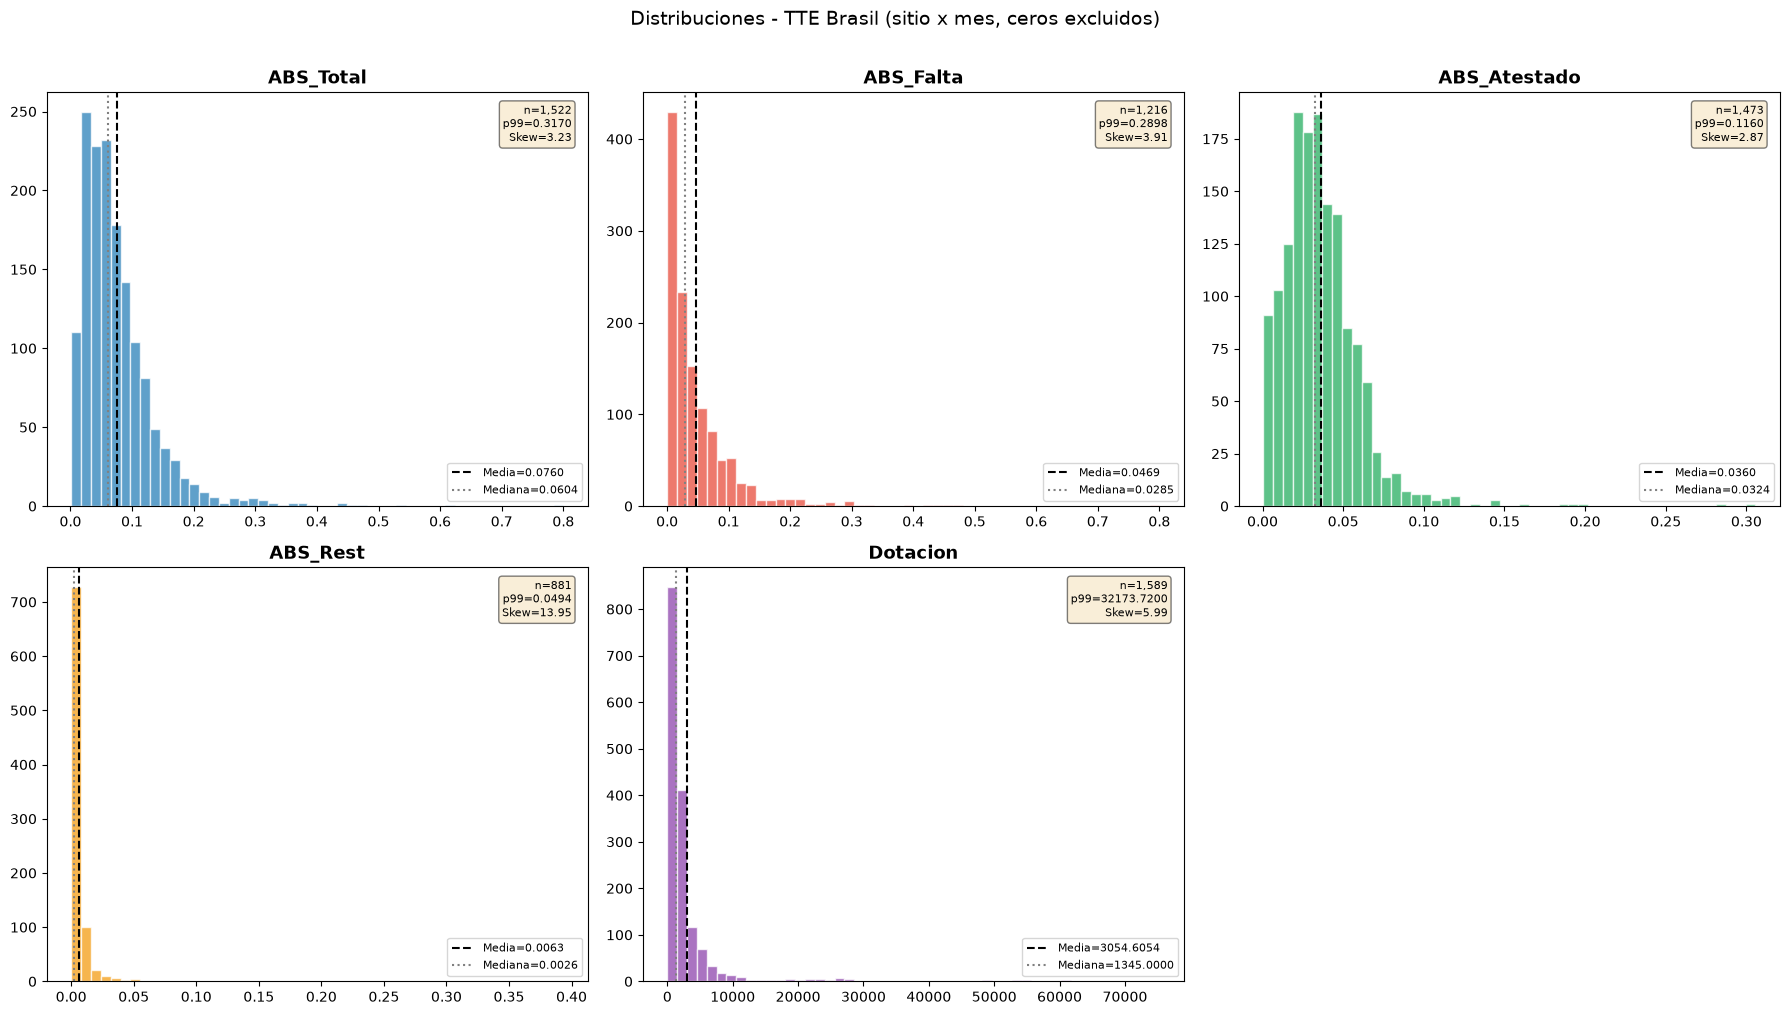


Estadisticas:


,n,Media,Mediana,Std,p5,p25,p75,p95,p99,Skewness,Kurtosis
Metrica,,,,,,,,,,,
ABS_Total,1522,0.0760,0.0604,0.0643,0.0133,0.0347,0.0974,0.1851,0.3170,3.2253,20.0930
ABS_Falta,1216,0.0469,0.0285,0.0608,0.0015,0.0093,0.0617,0.1433,0.2898,3.9088,28.1302
ABS_Atestado,1473,0.0360,0.0324,0.0246,0.0055,0.0204,0.0469,0.0733,0.1160,2.8689,20.8173
ABS_Rest,881,0.0063,0.0026,0.0190,0.0005,0.0013,0.0060,0.0179,0.0494,13.9549,243.0507
Dotacion,1589,"3,054.6054","1,345.0000","6,769.9346",67.8000,603.0000,"2,559.0000","10,011.6000","32,173.7200",5.9895,43.6302


In [16]:
mets    = ['ABS_Total','ABS_Falta','ABS_Atestado','ABS_Rest','Dotacion']
cols    = ['#2980b9','#e74c3c','#27ae60','#f39c12','#8e44ad']
fig, ax = plt.subplots(2, 3, figsize=(18,10))
ax      = ax.flatten()
rows    = []

for i,(met,color) in enumerate(zip(mets,cols)):
    d = df_pivot[met].dropna()
    d = d[d>0]
    ax[i].hist(d, bins=50, color=color, alpha=0.75, edgecolor='white')
    ax[i].axvline(d.mean(),   color='black', ls='--', lw=1.5, label=f'Media={d.mean():.4f}')
    ax[i].axvline(d.median(), color='gray',  ls=':',  lw=1.5, label=f'Mediana={d.median():.4f}')
    ax[i].set_title(met, fontsize=13, fontweight='bold')
    ax[i].legend(fontsize=8)
    ax[i].text(0.97,0.97,f'n={len(d):,}\np99={d.quantile(.99):.4f}\nSkew={d.skew():.2f}',
               transform=ax[i].transAxes, ha='right', va='top', fontsize=8,
               bbox=dict(boxstyle='round',facecolor='wheat',alpha=0.5))
    rows.append({'Metrica':met,'n':len(d),'Media':d.mean(),'Mediana':d.median(),
                 'Std':d.std(),'p5':d.quantile(.05),'p25':d.quantile(.25),
                 'p75':d.quantile(.75),'p95':d.quantile(.95),'p99':d.quantile(.99),
                 'Skewness':d.skew(),'Kurtosis':d.kurtosis()})

ax[-1].set_visible(False)
plt.suptitle('Distribuciones - TTE Brasil (sitio x mes, ceros excluidos)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('\nEstadisticas:')
display(pd.DataFrame(rows).set_index('Metrica').round(4))


---
#### — Detección y Tratamiento de Outliers

**Tres enfoques complementarios:**
1. **IQR (Tukey)** — robusto ante distribuciones asimétricas
2. **Z-score modificado (MAD)** — más robusto que el Z clásico ante heavy tails
3. **Boxplot interactivo** — para distinguir errores de picos estacionales reales

> En series de tiempo, un outlier puede ser real (brote de gripe, huelga, evento climático).  
> La decisión de winsorizar, marcar o eliminar se hace **explícitamente**, no de forma ciega.


In [17]:
def out_iqr(s, f=1.5):
    Q1,Q3 = s.quantile([.25,.75])
    return (s<Q1-f*(Q3-Q1)) | (s>Q3+f*(Q3-Q1))


def out_zmod(s, u=3.5):
    med = s.median()
    mad = (s-med).abs().median()
    if mad==0: return pd.Series(False, index=s.index)
    return (0.6745*(s-med)/mad).abs() > u


df_out = df_pivot[df_pivot['Dotacion']>0].copy()
for met in ['ABS_Total','ABS_Falta','ABS_Atestado','ABS_Rest']:
    s = df_out[met].fillna(0)
    df_out[f'{met}_oi'] = out_iqr(s)
    df_out[f'{met}_oz'] = out_zmod(s)
    df_out[f'{met}_ob'] = df_out[f'{met}_oi'] & df_out[f'{met}_oz']

rows = []
for met in ['ABS_Total','ABS_Falta','ABS_Atestado','ABS_Rest']:
    rows.append({'Metrica':met,
                 'IQR':df_out[f'{met}_oi'].sum(),
                 'Z-mod':df_out[f'{met}_oz'].sum(),
                 'Ambos (alta confianza)':df_out[f'{met}_ob'].sum()})
print('Resumen outliers (solo registros con Dotacion > 0):')
display(pd.DataFrame(rows).set_index('Metrica'))


Resumen outliers (solo registros con Dotacion > 0):


,IQR,Z-mod,Ambos (alta confianza)
Metrica,,,
ABS_Total,66,48,48
ABS_Falta,100,160,100
ABS_Atestado,38,20,20
ABS_Rest,159,318,159


In [18]:
# Boxplot interactivo Top 30 sitios por mediana ABS_Total
top30 = df_out.groupby('Operational_name')['ABS_Total'].median().sort_values(ascending=False).head(30).index.tolist()
fig = px.box(
    df_out[df_out['Operational_name'].isin(top30)],
    x='Operational_name', y='ABS_Total',
    category_orders={'Operational_name':top30},
    title='ABS_Total por Sitio - Top 30 por mediana (outliers como puntos)',
    color='Operational_name', points='outliers'
)
fig.update_layout(height=550, showlegend=False, xaxis_tickangle=-60, xaxis_title='')
fig.show()


In [19]:
# Tabla de outliers de alta confianza para revisión manual
cols_s = ['Operational_name','fecha_mes','Dotacion',
           'Falta_Inj','Atestados_Medicos','Rest_Abs_Gestionable',
           'ABS_Total','ABS_Falta','ABS_Atestado','ABS_Rest']
df_ohc = df_out[df_out['ABS_Total_ob']][[c for c in cols_s if c in df_out]].sort_values('ABS_Total',ascending=False)
print(f'Outliers alta confianza: {len(df_ohc):,} registros en {df_ohc["Operational_name"].nunique()} sitios')
print('Revisar caso por caso antes de decidir tratamiento.')
display(df_ohc)


Outliers alta confianza: 48 registros en 33 sitios
Revisar caso por caso antes de decidir tratamiento.


,Operational_name,fecha_mes,Dotacion,Falta_Inj,Atestados_Medicos,Rest_Abs_Gestionable,ABS_Total,ABS_Falta,ABS_Atestado,ABS_Rest
1576,XD - ZONA NORTE XSP16,2025-08-01,5.0000,4.0000,0.0000,0.0000,0.8000,0.8000,0.0000,0.0000
863,SC - SAO BERNARDO DO CAMPO SSP17,2026-04-01,"1,187.0000",255.0000,5.0000,467.0000,0.6125,0.2148,0.0042,0.3934
535,SC - MARINGA SPR6,2025-01-01,15.0000,7.0000,0.0000,1.0000,0.5333,0.4667,0.0000,0.0667
388,SC - ITAQUERA SSP45,2025-01-01,67.0000,28.0000,4.0000,0.0000,0.4776,0.4179,0.0597,0.0000
38,SC - ARACATUBA SSP10,2026-03-01,48.0000,22.0000,0.0000,0.0000,0.4583,0.4583,0.0000,0.0000
886,SC - SAPUCAIA DO SUL SRS8,2025-01-01,52.0000,23.0000,0.0000,0.0000,0.4423,0.4423,0.0000,0.0000
10,AH - GUARULHOS SSP19,2026-06-01,69.0000,20.0000,10.0000,0.0000,0.4348,0.2899,0.1449,0.0000
653,SC - MOOCA SSP21,2024-12-01,5.0000,2.0000,0.0000,0.0000,0.4000,0.4000,0.0000,0.0000
334,SC - GUARULHOS SSP19,2025-01-01,37.0000,10.0000,0.0000,4.0000,0.3784,0.2703,0.0000,0.1081
582,SC - MEGA BARUERI SSP5,2025-01-01,112.0000,36.0000,6.0000,0.0000,0.3750,0.3214,0.0536,0.0000


---
###  Análisis de Series Temporales por Sitio

**Estructura temporal antes de modelar:**
- ¿Los sitios muestran tendencia, estacionalidad o solo ruido?
- ¿Hay sitios con distintas fechas de inicio/fin (lifecycles)?
- ¿Cuántos meses reales tiene cada sitio?

Esto define el mínimo de historia requerido y la estrategia de feature engineering.


In [20]:
df_hist = df_pivot[df_pivot['Dotacion']>0].groupby('Operational_name').agg(
    fecha_inicio = ('fecha_mes','min'),
    fecha_fin    = ('fecha_mes','max'),
    n_meses      = ('fecha_mes','count'),
    dot_media    = ('Dotacion','mean'),
    abs_media    = ('ABS_Total','mean'),
    abs_std      = ('ABS_Total','std')
).reset_index()
df_hist['cv_abs'] = (df_hist['abs_std']/df_hist['abs_media']).round(3)
df_hist = df_hist.sort_values('n_meses',ascending=False)

print('Historia por sitio:')
print(f'  >= 18 meses: {(df_hist["n_meses"]>=18).sum()}')
print(f'  >= 12 meses: {(df_hist["n_meses"]>=12).sum()}')
print(f'  >=  6 meses: {(df_hist["n_meses"]>=6).sum()}')
print(f'   <  6 meses: {(df_hist["n_meses"]<6).sum()} (candidatos a excluir)')
display(df_hist)


Historia por sitio:
  >= 18 meses: 43
  >= 12 meses: 54
  >=  6 meses: 70
   <  6 meses: 19 (candidatos a excluir)


,Operational_name,fecha_inicio,fecha_fin,n_meses,dot_media,abs_media,abs_std,cv_abs
49,SC - SAPUCAIA DO SUL SRS8,2024-01-01,2026-08-01,46,"1,337.5870",0.0779,0.0745,0.9560
34,SC - MEGA BARUERI SSP5,2024-01-01,2026-08-01,35,"4,313.3143",0.0803,0.0626,0.7790
32,SC - MARINGA SPR6,2024-01-01,2026-08-01,34,"1,087.6765",0.0832,0.0901,1.0830
17,SC - GASPAR SSC3,2024-01-01,2026-08-01,33,"1,073.6364",0.0677,0.0480,0.7090
37,SC - MOOCA SSP21,2024-01-01,2026-08-01,33,"2,023.7576",0.0660,0.0724,1.0960
36,SC - MONTES CLAROS SMG7,2024-01-01,2026-08-01,33,562.8485,0.0589,0.0404,0.6850
22,SC - IPATINGA SMG4,2024-01-01,2026-08-01,33,470.6667,0.0443,0.0368,0.8300
11,SC - CONTAGEM SMG1,2024-01-01,2026-08-01,33,"1,977.7576",0.0933,0.0399,0.4270
8,SC - CAXIAS DO SUL SRS4,2024-01-01,2026-08-01,33,"1,099.8182",0.0713,0.0592,0.8300
30,SC - LONDRINA SPR2,2024-01-01,2026-08-01,33,"1,201.6364",0.0673,0.0474,0.7050


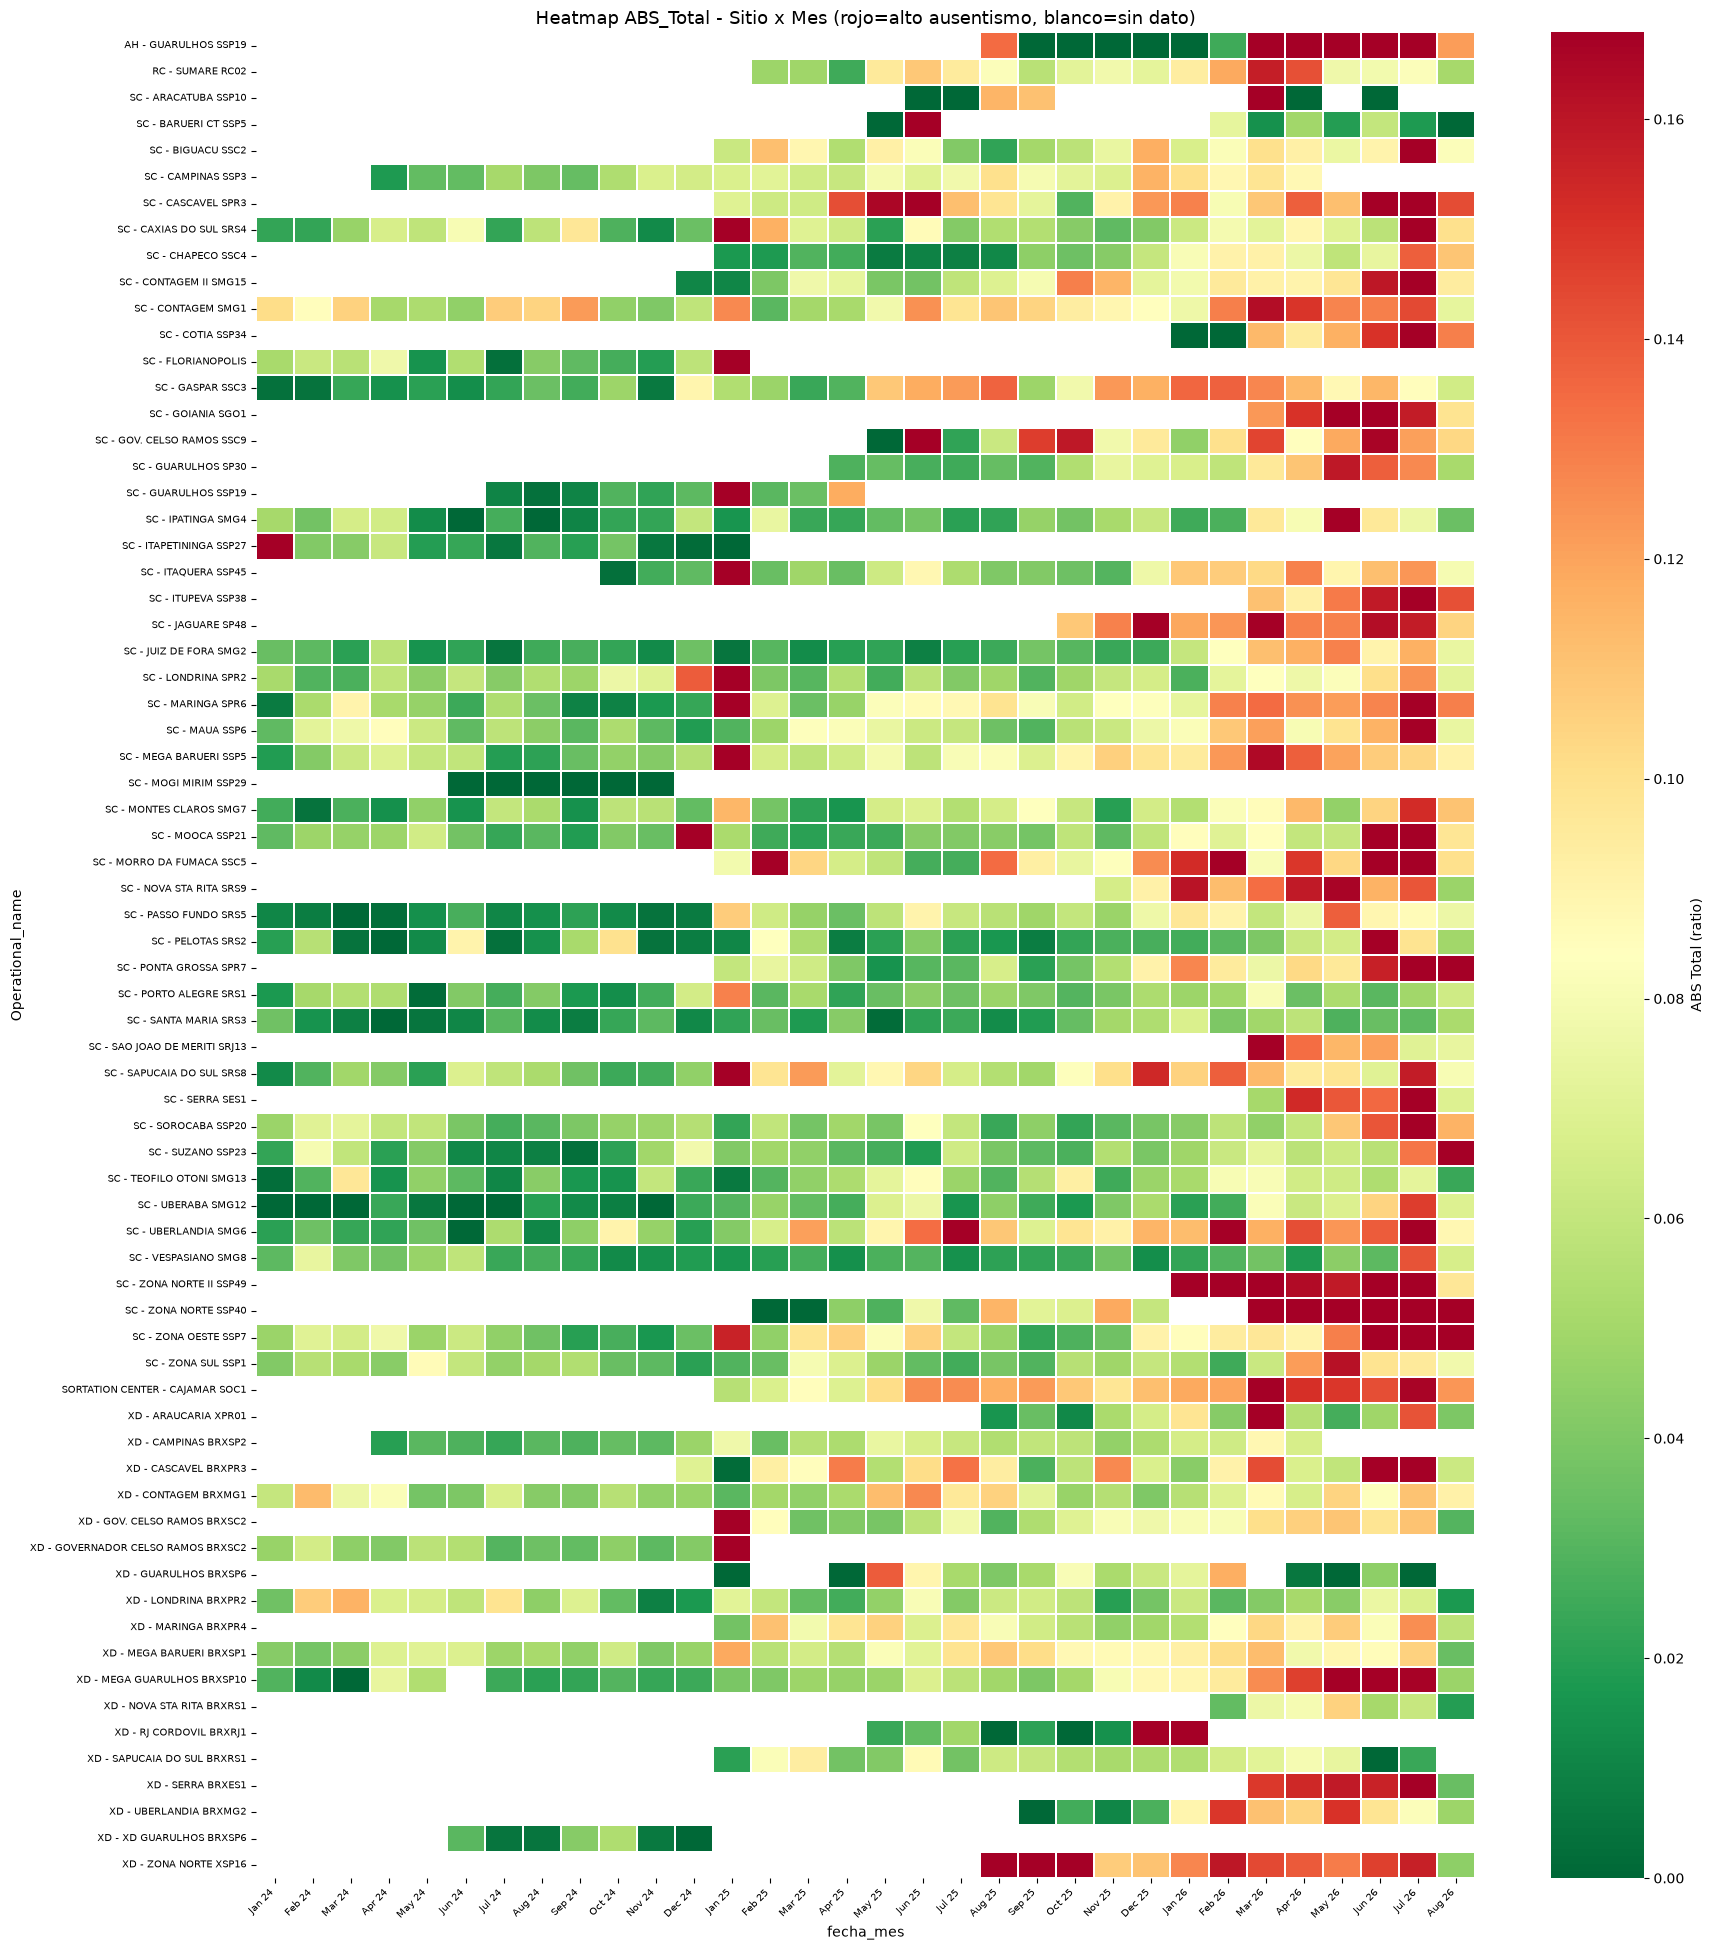

Meses: 32 | Sitios: 70


In [21]:
# Heatmap: ABS_Total por Sitio x Mes
sitios_ok = df_hist[df_hist['n_meses']>=6]['Operational_name'].tolist()
df_hm = df_pivot[
    df_pivot['Operational_name'].isin(sitios_ok) & (df_pivot['Dotacion']>0)
].pivot_table(index='Operational_name', columns='fecha_mes', values='ABS_Total')

fig, ax = plt.subplots(figsize=(18, max(8, len(sitios_ok)*0.28)))
sns.heatmap(df_hm, ax=ax, cmap='RdYlGn_r', annot=False, linewidths=0.3,
            vmin=0, vmax=df_hm.stack().quantile(0.95),
            cbar_kws={'label':'ABS Total (ratio)'})
ax.set_title('Heatmap ABS_Total - Sitio x Mes (rojo=alto ausentismo, blanco=sin dato)', fontsize=13)
ax.set_xticklabels(
    [pd.Timestamp(t.get_text()).strftime('%b %y') for t in ax.get_xticklabels()],
    rotation=45, ha='right', fontsize=7
)
ax.tick_params(axis='y', labelsize=7)
plt.tight_layout()
plt.show()
print(f'Meses: {df_hm.shape[1]} | Sitios: {df_hm.shape[0]}')


In [22]:
# Series temporales Top 6 sitios por dotacion media
top6 = df_pivot[df_pivot['Dotacion']>0].groupby('Operational_name')['Dotacion'].mean().nlargest(6).index.tolist()
fig  = make_subplots(rows=3, cols=2, subplot_titles=top6, vertical_spacing=0.12)
for i,site in enumerate(top6):
    r,c = divmod(i,2)
    ds  = df_pivot[df_pivot['Operational_name']==site].sort_values('fecha_mes')
    fig.add_trace(
        go.Scatter(x=ds['fecha_mes'], y=(ds['ABS_Total']*100).round(2),
                   mode='lines+markers', name='ABS%',
                   line=dict(color='#e74c3c',width=2), marker=dict(size=5)),
        row=r+1, col=c+1
    )
fig.update_layout(height=800, showlegend=False, template='plotly_white',
                  title_text='Series ABS_Total - Top 6 sitios por Dotacion media')
fig.update_yaxes(title_text='ABS %')
fig.show()


---
## Hallazgos de esta fase (completar al ejecutar)

| # | Hallazgo | Decisión |
|---|---|---|
| 1 | | |
| 2 | | |
| 3 | | |

---

## Próximos notebooks

| Notebook | Qué haremos |
|---|---|
| **v1 — Limpieza** | Tratamiento de outliers, gaps, sitios a excluir |
| **v2 — Feature Engineering** | Lags, rolling, estacionalidad, covariables externas |
| **v3 — Modelado ABS** | Benchmark: Naive, SARIMA, CatBoost/LGBM, modelos fundacionales |
| **v4 — Modelado TO** | Mismo proceso para Turnover |
| **v5 — Validación** | Walk-forward riguroso, métricas por sitio |
| **v6 — Producción** | Pipeline completo, schedule mensual |


---
### Modelado: Naive Estacional (Baseline)

**El modelo mas simple posible: para cada sitio, la prediccion de cada mes es
el promedio historico de ese mismo mes en los anios anteriores.**

Ejemplo: prediccion Feb 2026 = avg(Feb 2024, Feb 2025) por sitio.

| Parametro | Valor |
|---|---|
| Train | ene 2024 → ene 2026 |
| Validacion | feb 2026 → jul 2026 (6 meses, horizonte real) |
| Sitios elegibles | >= 6 meses de train con Dotacion > 0 |
| Metrica | MAPE sobre ABS_Total (ratio ausentismo/dotacion) |

Si un modelo complejo no supera este baseline, el modelo complejo esta mal.
Referencia Jhony CatBoost walk-forward: ~38.56%

In [23]:
# Setup: cutoff, split y sitios elegibles
CUTOFF    = pd.Timestamp('2026-01-31')
VAL_START = pd.Timestamp('2026-02-01')
VAL_END   = pd.Timestamp('2026-07-31')
MIN_MESES_TRAIN = 6

df_work = df_pivot[df_pivot['Dotacion'] > 0].copy()
df_tr   = df_work[df_work['fecha_mes'] <= CUTOFF].copy()
df_va   = df_work[(df_work['fecha_mes'] >= VAL_START) & (df_work['fecha_mes'] <= VAL_END)].copy()

sitios_ok = (
    df_tr.groupby('Operational_name')['fecha_mes'].count()
    .loc[lambda s: s >= MIN_MESES_TRAIN].index
)
df_tr = df_tr[df_tr['Operational_name'].isin(sitios_ok)].copy()
df_va = df_va[df_va['Operational_name'].isin(sitios_ok)].copy()

print(f'Cutoff     : train <= {CUTOFF.strftime("%Y-%m")},  val {VAL_START.strftime("%Y-%m")} -> {VAL_END.strftime("%Y-%m")}')
print(f'Sitios OK  : {len(sitios_ok)} (de {df_pivot["Operational_name"].nunique()} totales)')
print(f'Filas train: {len(df_tr):,}  |  Filas val: {len(df_va):,}')

meses_por_sitio = df_tr.groupby('Operational_name')['fecha_mes'].count()
print(f'\nMeses en train por sitio:')
print(f'  >= 18 meses: {(meses_por_sitio >= 18).sum()}')
print(f'  12-17 meses: {((meses_por_sitio >= 12) & (meses_por_sitio < 18)).sum()}')
print(f'   6-11 meses: {((meses_por_sitio >= 6)  & (meses_por_sitio < 12)).sum()}')

Cutoff     : train <= 2026-01,  val 2026-02 -> 2026-07
Sitios OK  : 57 (de 89 totales)
Filas train: 1,088  |  Filas val: 294

Meses en train por sitio:
  >= 18 meses: 30
  12-17 meses: 16
   6-11 meses: 11


In [24]:
# Naive Estacional: pred = avg historico por sitio x mes_del_anio
df_tr['mes'] = df_tr['fecha_mes'].dt.month
naive_map = (
    df_tr.groupby(['Operational_name', 'mes'])['ABS_Total']
    .mean().reset_index().rename(columns={'ABS_Total': 'pred'})
)

# Fallback: media global del sitio (para meses nunca vistos en train)
media_sitio = df_tr.groupby('Operational_name')['ABS_Total'].mean().rename('pred_global')

df_va['mes'] = df_va['fecha_mes'].dt.month
df_va = df_va.merge(naive_map,   on=['Operational_name', 'mes'], how='left')
df_va = df_va.merge(media_sitio, on='Operational_name',           how='left')
df_va['pred'] = df_va['pred'].fillna(df_va['pred_global'])

# MAPE (excluir actuals == 0)
mask = df_va['ABS_Total'] > 0
df_va['APE'] = np.where(
    mask,
    np.abs(df_va['ABS_Total'] - df_va['pred']) / df_va['ABS_Total'],
    np.nan
)

mape_global = df_va['APE'].mean() * 100
print(f'NAIVE ESTACIONAL — MAPE GLOBAL: {mape_global:.2f}%')
print(f'(Referencia Jhony CatBoost walk-forward: ~38.56%)')

mape_por_sitio = (
    df_va.groupby('Operational_name')['APE'].mean().mul(100)
    .reset_index().rename(columns={'APE': 'MAPE_%'}).sort_values('MAPE_%')
)
desc = mape_por_sitio['MAPE_%'].describe()
print(f'\nDistribucion MAPE por sitio:')
print(f'  Mediana : {desc["50%"]:.1f}%')
print(f'  p25/p75 : {desc["25%"]:.1f}% / {desc["75%"]:.1f}%')
print(f'  Min/Max : {desc["min"]:.1f}% / {desc["max"]:.1f}%')
print(f'\n--- Mejores 10 sitios ---')
display(mape_por_sitio.head(10).reset_index(drop=True))
print(f'\n--- Peores 10 sitios ---')
display(mape_por_sitio.tail(10).reset_index(drop=True))

NAIVE ESTACIONAL — MAPE GLOBAL: 50.97%
(Referencia Jhony CatBoost walk-forward: ~38.56%)

Distribucion MAPE por sitio:
  Mediana : 50.4%
  p25/p75 : 39.3% / 58.5%
  Min/Max : 17.2% / 86.2%

--- Mejores 10 sitios ---


,Operational_name,MAPE_%
0,XD - CONTAGEM BRXMG1,17.2077
1,XD - MARINGA BRXPR4,17.6465
2,XD - MEGA BARUERI BRXSP1,31.2437
3,SC - CASCAVEL SPR3,31.9253
4,SC - PORTO ALEGRE SRS1,32.8713
5,SC - TEOFILO OTONI SMG13,33.2433
6,SC - BIGUACU SSC2,33.2488
7,XD - CASCAVEL BRXPR3,35.6151
8,SORTATION CENTER - CAJAMAR SOC1,36.0470
9,SC - CAMPINAS SSP3,36.4175



--- Peores 10 sitios ---


,Operational_name,MAPE_%
0,SC - GUARULHOS SP30,65.1526
1,XD - MEGA GUARULHOS BRXSP10,69.5884
2,SC - IPATINGA SMG4,72.1104
3,XD - ZONA NORTE XSP16,75.8523
4,SC - JUIZ DE FORA SMG2,78.7359
5,AH - GUARULHOS SSP19,79.4148
6,SC - PELOTAS SRS2,80.3166
7,SC - CHAPECO SSC4,80.5940
8,XD - GUARULHOS BRXSP6,84.7262
9,SC - ZONA NORTE SSP40,86.2263


In [25]:
# Visualizacion: MAPE por sitio (barras ordenadas)
fig = px.bar(
    mape_por_sitio,
    x='Operational_name', y='MAPE_%',
    color='MAPE_%',
    color_continuous_scale='RdYlGn_r',
    title=f'MAPE por Sitio — Naive Estacional (val feb-jul 2026)  |  Global: {mape_global:.1f}%',
    labels={'MAPE_%': 'MAPE %', 'Operational_name': ''}
)
fig.add_hline(y=mape_global, line_dash='dash', line_color='navy',
              annotation_text=f'Media: {mape_global:.1f}%', annotation_position='top left')
fig.update_layout(height=480, xaxis_tickangle=-65, coloraxis_showscale=False)
fig.show()

# Scatter: prediccion vs real en validacion
mask = df_va['ABS_Total'] > 0
fig2 = px.scatter(
    df_va[mask], x='ABS_Total', y='pred',
    hover_data=['Operational_name', 'fecha_mes'],
    opacity=0.6,
    title='Prediccion vs Real — Naive Estacional (cada punto = sitio x mes)',
    labels={'ABS_Total': 'Real ABS_Total', 'pred': 'Prediccion Naive'}
)
lim = max(df_va[mask]['ABS_Total'].max(), df_va[mask]['pred'].max()) * 1.05
fig2.add_shape(type='line', x0=0, y0=0, x1=lim, y1=lim,
               line=dict(color='red', dash='dot', width=1))
fig2.update_layout(height=450)
fig2.show()